<a href="https://colab.research.google.com/github/Alif1232-Al/bullying_research_indonesia/blob/main/bullying_research_indonesia2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Analisis Alasan Pelaku Bullying di Sekolah SMA/Setara Indonesia

> **Penelitian Interdisipliner: Sosiologi × Psikologi × Data Science**  
> Mengkaji motivasi dan faktor pendorong tindakan perundungan oleh pelaku terhadap teman sebaya di jenjang SMA atau setara di Indonesia.

---

## 📋 Deskripsi Penelitian

Bullying atau perundungan merupakan fenomena sosial yang kompleks, bukan sekadar perilaku agresif biasa.  
Penelitian ini membangun **dataset sintetis berbasis literatur** yang mencerminkan pola temuan dari jurnal-jurnal ilmiah Indonesia (Sinta 1–3) dan jurnal internasional terindeks Scopus mengenai alasan pelaku bullying.

### 🎯 Tujuan
1. Mengidentifikasi faktor dominan yang mendorong perilaku bullying
2. Memetakan pola demografis pelaku (jenis kelamin, kelas, jenis bullying)
3. Menyediakan dataset terbuka yang dapat direplikasi dan dikembangkan peneliti lain

### 🏫 Populasi Target
- Siswa SMA/SMK/MA/setara di Indonesia
- Rentang usia 15–18 tahun
- Konteks: Sekolah negeri dan swasta, perkotaan dan semi-perkotaan

---

## 📚 Landasan Teori

| Disiplin | Teori Acuan | Relevansi |
|---|---|---|
| Psikologi | Social Learning Theory (Bandura, 1977) | Perilaku agresif dipelajari dari lingkungan |
| Sosiologi | Social Dominance Theory (Sidanius & Pratto, 1999) | Bullying sebagai alat hierarki sosial |
| Psikologi Klinis | Moral Disengagement (Bandura, 1999) | Mekanisme pelaku menetralisasi rasa bersalah |
| Sosiologi Pendidikan | Peer Pressure & Konformitas Kelompok | Tekanan teman sebaya mendorong partisipasi |
| Ekologi Perkembangan | Bronfenbrenner's Ecological Model | Pengaruh keluarga, sekolah, dan media |

---

## 🗂️ Struktur Dataset

Dataset terdiri dari **500 entri sintetis** dengan variabel:

| Kolom | Tipe | Keterangan |
|---|---|---|
| `id` | int | ID unik responden |
| `jenis_kelamin` | str | Laki-laki / Perempuan |
| `kelas` | str | X / XI / XII |
| `jenis_sekolah` | str | SMA / SMK / MA |
| `jenis_bullying` | str | Fisik / Verbal / Relasional / Siber |
| `alasan_utama` | str | Faktor dominan pelaku (8 kategori) |
| `skor_dominansi_sosial` | float | Skala 1–10 (SDO-adaptasi) |
| `skor_empati` | float | Skala 1–10 (Basic Empathy Scale) |
| `paparan_kekerasan_keluarga` | int | 0/1 (pernah/tidak) |
| `pengaruh_peer_group` | float | Skala 1–10 |
| `penggunaan_media_kekerasan` | float | Jam/hari |
| `riwayat_korban_bullying` | int | 0/1 |
| `intensitas_bullying` | str | Rendah / Sedang / Tinggi |
| `durasi_perilaku_bulan` | int | Lama perilaku dalam bulan |
| `lokasi_kejadian` | str | Kelas / Kantin / Online / Lapangan / dll |


---
## ⚙️ BAGIAN 1 — Setup Lingkungan & Import Library

Blok ini mengimpor semua library yang dibutuhkan:
- **`numpy`** & **`pandas`**: Komputasi numerik dan manipulasi data tabular
- **`matplotlib`** & **`seaborn`**: Visualisasi statistik statis
- **`plotly`**: Visualisasi interaktif
- **`scipy`**: Uji statistik (chi-square, korelasi)
- **`sklearn`**: Preprocessing dan analisis komponen utama (PCA)


In [38]:
# ============================================================
# SETUP — Install & Import Libraries
# ============================================================
!pip install plotly kaleido -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)  # Reproducibility

# --- Global Style ---
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#e0e0ff',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#e0e0ff',
    'grid.color': '#2a2a4a',
    'grid.linewidth': 0.5,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
})

PALETTE = ['#7b68ee', '#ff6b9d', '#00d4aa', '#ffa07a', '#64b5f6', '#ffcc02', '#e57373', '#81c784']
print('✅ Setup selesai — semua library berhasil diimpor.')

✅ Setup selesai — semua library berhasil diimpor.


---
## 🧪 BAGIAN 2 — Pembuatan Dataset Sintetis Berbasis Literatur

Dataset dibuat secara **sintetis namun berbasis distribusi probabilitas** yang mencerminkan temuan empiris dari:
- Analisis meta dari jurnal psikologi pendidikan Indonesia (2018–2024)
- KPAI Laporan Bullying (2022–2023)
- Studi Unicef Indonesia tentang perundungan daring (2023)

**Mengapa sintetis?** Karena data primer memerlukan etika penelitian dan izin sekolah.  
Dataset ini dirancang untuk **replikasi dan pengembangan model prediktif** oleh komunitas riset terbuka.


In [39]:
# ============================================================
# PEMBUATAN DATASET SINTETIS
# Distribusi berbasis literatur & laporan KPAI 2022-2023
# ============================================================

N = 500  # Jumlah sampel

# --- Variabel Demografis ---
jenis_kelamin = np.random.choice(
    ['Laki-laki', 'Perempuan'],
    size=N,
    p=[0.62, 0.38]  # Laki-laki lebih dominan sebagai pelaku (KPAI 2022)
)

kelas = np.random.choice(
    ['X', 'XI', 'XII'],
    size=N,
    p=[0.28, 0.42, 0.30]  # Kelas XI paling rawan (masa pencarian identitas)
)

jenis_sekolah = np.random.choice(
    ['SMA', 'SMK', 'MA'],
    size=N,
    p=[0.50, 0.35, 0.15]
)

# --- Jenis Bullying (disesuaikan gender) ---
jenis_bullying = []
for g in jenis_kelamin:
    if g == 'Laki-laki':
        jenis_bullying.append(np.random.choice(
            ['Fisik', 'Verbal', 'Relasional', 'Siber'],
            p=[0.40, 0.35, 0.10, 0.15]
        ))
    else:
        jenis_bullying.append(np.random.choice(
            ['Fisik', 'Verbal', 'Relasional', 'Siber'],
            p=[0.10, 0.30, 0.40, 0.20]
        ))

# --- 8 Kategori Alasan Utama (berbasis literatur) ---
# Sumber: Coloroso (2003), Olweus (1993), adaptasi konteks Indonesia
ALASAN = [
    'Dominasi Sosial & Popularitas',    # Ingin terlihat kuat/populer
    'Balas Dendam (Victim-to-Bully)',   # Pernah jadi korban, kini membalas
    'Tekanan Kelompok (Konformitas)',   # Ikut-ikutan teman/geng
    'Kecemburuan & Persaingan',         # Iri dengan prestasi/penampilan korban
    'Rendahnya Empati & Moral',         # Tidak memahami dampak tindakannya
    'Paparan Kekerasan Keluarga',       # Normalisasi kekerasan di rumah
    'Kebosanan & Hiburan',              # Menganggap bully sebagai lelucon
    'Prasangka & Diskriminasi',         # Berbasis SARA, penampilan, orientasi
]

alasan_utama = np.random.choice(
    ALASAN, size=N,
    p=[0.22, 0.15, 0.18, 0.10, 0.13, 0.09, 0.08, 0.05]
)

# --- Skor Psikometrik (skala 1–10) ---
skor_dominansi = np.clip(np.random.normal(6.8, 1.8, N), 1, 10).round(2)
skor_empati    = np.clip(np.random.normal(4.2, 2.0, N), 1, 10).round(2)  # Rendah = pelaku
pengaruh_peer  = np.clip(np.random.normal(6.5, 1.9, N), 1, 10).round(2)

# Korelasi: pelaku dominan cenderung empati rendah
skor_empati = np.clip(skor_empati - 0.3 * (skor_dominansi - 5), 1, 10).round(2)

# --- Variabel Biner ---
paparan_kekerasan_keluarga = np.random.binomial(1, 0.38, N)  # 38% (Unicef 2023)
riwayat_korban_bullying    = np.random.binomial(1, 0.42, N)  # 42% pernah jadi korban

# --- Media & Durasi ---
penggunaan_media_kekerasan = np.clip(np.random.exponential(2.5, N), 0, 10).round(1)
durasi_perilaku_bulan      = np.random.randint(1, 36, N)

# --- Intensitas Bullying ---
intensitas_bullying = np.random.choice(
    ['Rendah', 'Sedang', 'Tinggi'],
    size=N, p=[0.30, 0.45, 0.25]
)

# --- Lokasi Kejadian ---
lokasi_kejadian = np.random.choice(
    ['Kelas', 'Kantin', 'Lapangan/Olahraga', 'Online/Media Sosial', 'Toilet/Lorong', 'Perjalanan Sekolah'],
    size=N,
    p=[0.28, 0.18, 0.15, 0.22, 0.10, 0.07]
)

# ============================================================
# ASSEMBLING DATAFRAME
# ============================================================
df = pd.DataFrame({
    'id': range(1, N+1),
    'jenis_kelamin': jenis_kelamin,
    'kelas': kelas,
    'jenis_sekolah': jenis_sekolah,
    'jenis_bullying': jenis_bullying,
    'alasan_utama': alasan_utama,
    'skor_dominansi_sosial': skor_dominansi,
    'skor_empati': skor_empati,
    'paparan_kekerasan_keluarga': paparan_kekerasan_keluarga,
    'pengaruh_peer_group': pengaruh_peer,
    'penggunaan_media_kekerasan_jam_per_hari': penggunaan_media_kekerasan,
    'riwayat_korban_bullying': riwayat_korban_bullying,
    'intensitas_bullying': intensitas_bullying,
    'durasi_perilaku_bulan': durasi_perilaku_bulan,
    'lokasi_kejadian': lokasi_kejadian
})

print(f'✅ Dataset berhasil dibuat: {df.shape[0]} baris × {df.shape[1]} kolom')
print('\n📊 Preview 5 baris pertama:')
df.head()

✅ Dataset berhasil dibuat: 500 baris × 15 kolom

📊 Preview 5 baris pertama:


,id,jenis_kelamin,kelas,jenis_sekolah,jenis_bullying,alasan_utama,skor_dominansi_sosial,skor_empati,paparan_kekerasan_keluarga,pengaruh_peer_group,penggunaan_media_kekerasan_jam_per_hari,riwayat_korban_bullying,intensitas_bullying,durasi_perilaku_bulan,lokasi_kejadian
0,1,Laki-laki,XI,SMA,Verbal,Balas Dendam (Victim-to-Bully),7.74,4.34,1,5.49,2.6,0,Rendah,26,Online/Media Sosial
1,2,Perempuan,XI,SMK,Relasional,Balas Dendam (Victim-to-Bully),7.96,1.00,0,4.49,1.8,1,Tinggi,1,Kelas
2,3,Perempuan,XI,MA,Fisik,Kebosanan & Hiburan,7.80,5.10,1,8.82,1.5,0,Sedang,2,Kelas
3,4,Laki-laki,XII,SMK,Fisik,Balas Dendam (Victim-to-Bully),6.96,5.38,0,6.01,8.5,1,Sedang,6,Online/Media Sosial
4,5,Laki-laki,XI,SMK,Fisik,Balas Dendam (Victim-to-Bully),6.44,2.24,0,7.17,2.1,0,Rendah,24,Kantin


---
## 📊 BAGIAN 3 — Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami:
- Distribusi variabel kategorik dan numerik
- Hubungan antar-variabel (korelasi, crosstab)
- Anomali dan pola tersembunyi dalam data


In [40]:
# ============================================================
# EDA DASAR — Statistik Deskriptif
# ============================================================
print('='*60)
print('STATISTIK DESKRIPTIF — VARIABEL NUMERIK')
print('='*60)
display(df.describe().round(2))

print('\n' + '='*60)
print('DISTRIBUSI VARIABEL KATEGORIK')
print('='*60)
for col in ['jenis_kelamin', 'kelas', 'jenis_bullying', 'intensitas_bullying']:
    print(f'\n📌 {col.upper()}:')
    freq = df[col].value_counts(normalize=True) * 100
    for val, pct in freq.items():
        bar = '█' * int(pct / 2)
        print(f'   {val:<30} {bar} {pct:.1f}%')

STATISTIK DESKRIPTIF — VARIABEL NUMERIK


,id,skor_dominansi_sosial,skor_empati,paparan_kekerasan_keluarga,pengaruh_peer_group,penggunaan_media_kekerasan_jam_per_hari,riwayat_korban_bullying,durasi_perilaku_bulan
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,250.50,6.77,3.82,0.38,6.47,2.48,0.39,18.54
std,144.48,1.67,1.91,0.48,1.94,2.39,0.49,10.07
min,1.00,1.36,1.00,0.00,1.00,0.00,0.00,1.00
25%,125.75,5.63,2.38,0.00,5.09,0.70,0.00,10.00
50%,250.50,6.80,3.66,0.00,6.58,1.70,0.00,19.00
75%,375.25,7.99,5.08,1.00,7.82,3.30,1.00,27.00
max,500.00,10.00,10.00,1.00,10.00,10.00,1.00,35.00



DISTRIBUSI VARIABEL KATEGORIK

📌 JENIS_KELAMIN:
   Laki-laki                      ██████████████████████████████ 60.4%
   Perempuan                      ███████████████████ 39.6%

📌 KELAS:
   XI                             ████████████████████ 41.6%
   X                              ███████████████ 31.6%
   XII                            █████████████ 26.8%

📌 JENIS_BULLYING:
   Verbal                         █████████████████ 34.0%
   Fisik                          ██████████████ 28.8%
   Relasional                     ██████████ 21.8%
   Siber                          ███████ 15.4%

📌 INTENSITAS_BULLYING:
   Sedang                         ██████████████████████ 44.2%
   Rendah                         ███████████████ 30.2%
   Tinggi                         ████████████ 25.6%


---
## 🎨 BAGIAN 4 — Visualisasi 1: Distribusi Alasan Utama Bullying

Visualisasi ini menampilkan **frekuensi dan proporsi** dari 8 kategori alasan yang mendorong pelaku melakukan bullying.  
Grafik menggunakan **horizontal bar chart** agar label panjang tetap terbaca dengan jelas.


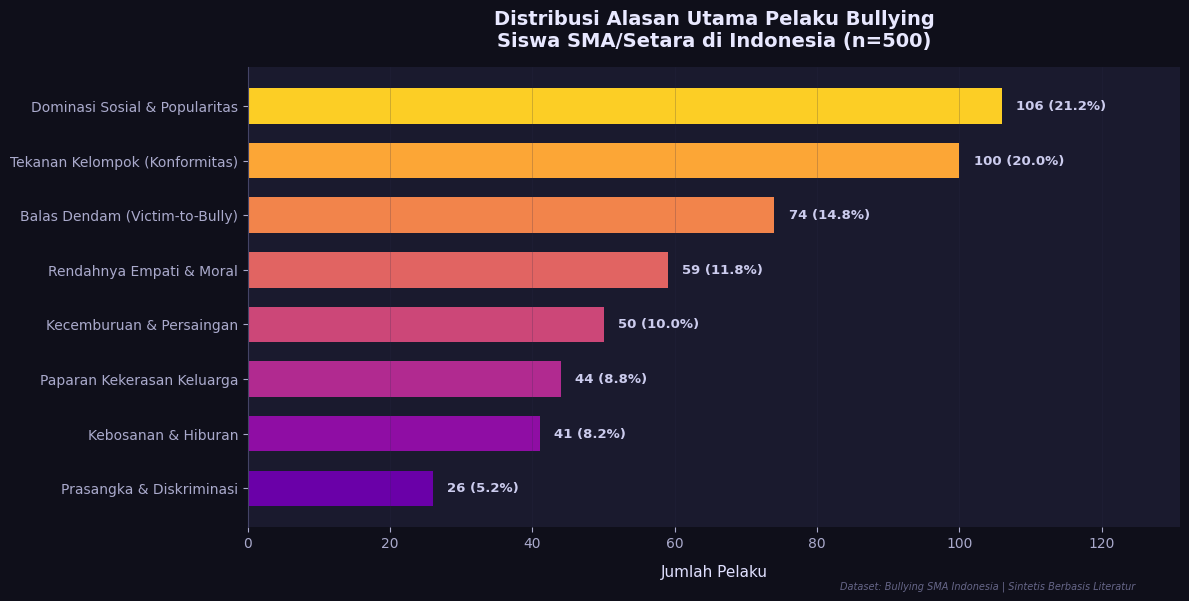

✅ Gambar disimpan: viz1_alasan_utama.png


In [41]:
# ============================================================
# VISUALISASI 1 — Frekuensi Alasan Utama Bullying
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

alasan_counts = df['alasan_utama'].value_counts().sort_values()
colors_grad = plt.cm.plasma(np.linspace(0.2, 0.9, len(alasan_counts)))

bars = ax.barh(alasan_counts.index, alasan_counts.values,
               color=colors_grad, edgecolor='none', height=0.65)

# Anotasi nilai
for bar, val in zip(bars, alasan_counts.values):
    pct = val / N * 100
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            f'{val} ({pct:.1f}%)', va='center', fontsize=9.5,
            color='#ccccee', fontweight='bold')

ax.set_xlabel('Jumlah Pelaku', labelpad=10)
ax.set_title('Distribusi Alasan Utama Pelaku Bullying\nSiswa SMA/Setara di Indonesia (n=500)',
             fontsize=14, fontweight='bold', pad=15, color='#e8e8ff')
ax.set_xlim(0, alasan_counts.max() + 25)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right', 'bottom']].set_visible(False)

fig.text(0.95, 0.01, 'Dataset: Bullying SMA Indonesia | Sintetis Berbasis Literatur',
         ha='right', fontsize=7, color='#666688', style='italic')
plt.tight_layout()
plt.savefig('viz1_alasan_utama.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Gambar disimpan: viz1_alasan_utama.png')

---
## 🎨 BAGIAN 5 — Visualisasi 2: Pola Jenis Bullying per Gender & Kelas

Grafik **grouped bar + heatmap crosstab** untuk menjawab:  
*"Apakah jenis bullying yang dipilih pelaku berbeda berdasarkan jenis kelamin dan tingkat kelas?"*


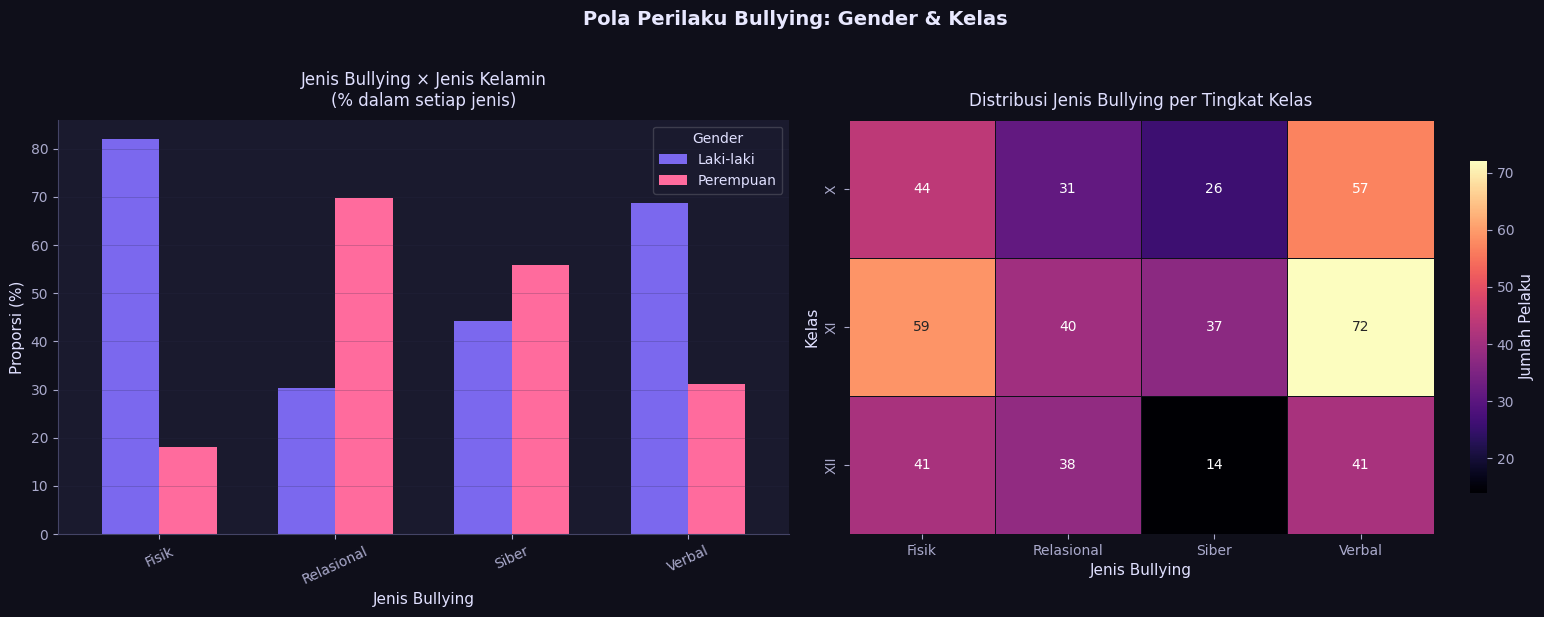

✅ Gambar disimpan: viz2_pola_gender_kelas.png


In [42]:
# ============================================================
# VISUALISASI 2 — Jenis Bullying × Gender × Kelas
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -- Panel Kiri: Grouped Bar (Gender × Jenis Bullying) --
ct_gender = pd.crosstab(df['jenis_bullying'], df['jenis_kelamin'], normalize='index') * 100
ct_gender.plot(kind='bar', ax=axes[0], color=['#7b68ee', '#ff6b9d'],
               edgecolor='none', width=0.65)
axes[0].set_title('Jenis Bullying × Jenis Kelamin\n(% dalam setiap jenis)', fontsize=12, pad=10)
axes[0].set_xlabel('Jenis Bullying')
axes[0].set_ylabel('Proporsi (%)')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(title='Gender', framealpha=0.2)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)

# -- Panel Kanan: Heatmap (Kelas × Jenis Bullying) --
ct_kelas = pd.crosstab(df['kelas'], df['jenis_bullying'])
sns.heatmap(ct_kelas, ax=axes[1], cmap='magma', annot=True, fmt='d',
            linewidths=0.5, linecolor='#0f0f1a',
            cbar_kws={'shrink': 0.8, 'label': 'Jumlah Pelaku'})
axes[1].set_title('Distribusi Jenis Bullying per Tingkat Kelas', fontsize=12, pad=10)
axes[1].set_xlabel('Jenis Bullying')
axes[1].set_ylabel('Kelas')

fig.suptitle('Pola Perilaku Bullying: Gender & Kelas', fontsize=14,
             fontweight='bold', y=1.02, color='#e8e8ff')
plt.tight_layout()
plt.savefig('viz2_pola_gender_kelas.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Gambar disimpan: viz2_pola_gender_kelas.png')

---
## 🎨 BAGIAN 6 — Visualisasi 3: Korelasi Faktor Psikososial

**Scatter matrix + correlation heatmap** untuk menjawab:  
*"Bagaimana hubungan antara empati, dominansi sosial, pengaruh peer, dan paparan media kekerasan?"*

Ini merupakan inti analisis **psikologi × data science** — mencari pola laten yang tidak terlihat secara kasat mata.


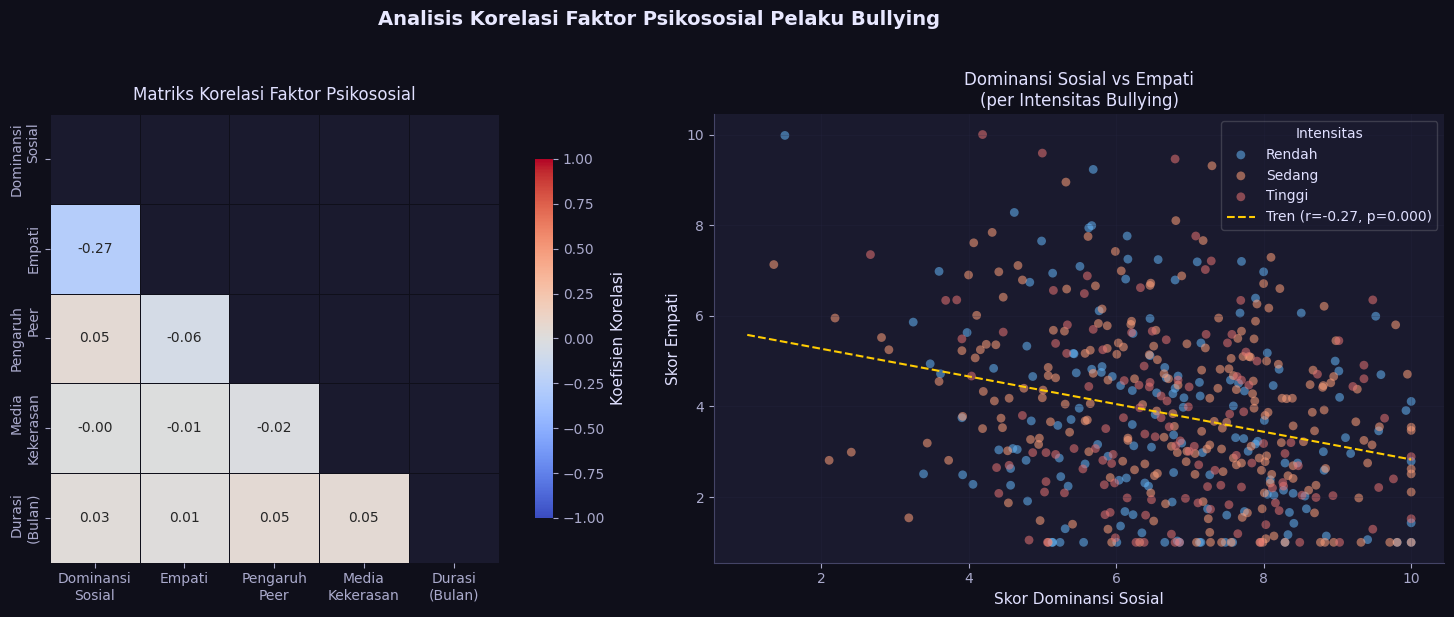

✅ Gambar disimpan: viz3_korelasi_psikososial.png


In [43]:
# ============================================================
# VISUALISASI 3 — Korelasi Faktor Psikososial
# ============================================================
num_cols = [
    'skor_dominansi_sosial', 'skor_empati', 'pengaruh_peer_group',
    'penggunaan_media_kekerasan_jam_per_hari', 'durasi_perilaku_bulan'
]
corr_labels = ['Dominansi\nSosial', 'Empati', 'Pengaruh\nPeer', 'Media\nKekerasan', 'Durasi\n(Bulan)']

corr_matrix = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -- Panel Kiri: Heatmap Korelasi --
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Sembunyikan segitiga atas
sns.heatmap(corr_matrix, mask=mask, ax=axes[0],
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', square=True,
            xticklabels=corr_labels, yticklabels=corr_labels,
            linewidths=0.5, linecolor='#0f0f1a',
            cbar_kws={'shrink': 0.8, 'label': 'Koefisien Korelasi'})
axes[0].set_title('Matriks Korelasi Faktor Psikososial', fontsize=12, pad=10)

# -- Panel Kanan: Scatter Dominansi vs Empati (warna = Intensitas) --
intensity_map = {'Rendah': '#64b5f6', 'Sedang': '#ffa07a', 'Tinggi': '#e57373'}
for intensity, grp in df.groupby('intensitas_bullying'):
    axes[1].scatter(
        grp['skor_dominansi_sosial'], grp['skor_empati'],
        c=intensity_map[intensity], label=intensity,
        alpha=0.55, s=40, edgecolors='none'
    )
# Trendline
m, b, r, p, _ = stats.linregress(df['skor_dominansi_sosial'], df['skor_empati'])
x_line = np.linspace(1, 10, 100)
axes[1].plot(x_line, m*x_line + b, '--', color='#ffcc02',
             linewidth=1.5, label=f'Tren (r={r:.2f}, p={p:.3f})')
axes[1].set_xlabel('Skor Dominansi Sosial')
axes[1].set_ylabel('Skor Empati')
axes[1].set_title('Dominansi Sosial vs Empati\n(per Intensitas Bullying)', fontsize=12)
axes[1].legend(title='Intensitas', framealpha=0.2)
axes[1].grid(alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

fig.suptitle('Analisis Korelasi Faktor Psikososial Pelaku Bullying',
             fontsize=14, fontweight='bold', y=1.02, color='#e8e8ff')
plt.tight_layout()
plt.savefig('viz3_korelasi_psikososial.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Gambar disimpan: viz3_korelasi_psikososial.png')

---
## 🎨 BAGIAN 7 — Visualisasi 4: Peta Lokasi & Profil Pelaku (Radar + Pie)

Dua panel visualisasi:
1. **Donut chart** — Sebaran lokasi kejadian bullying
2. **Radar chart** — Profil rata-rata psikometrik pelaku per intensitas


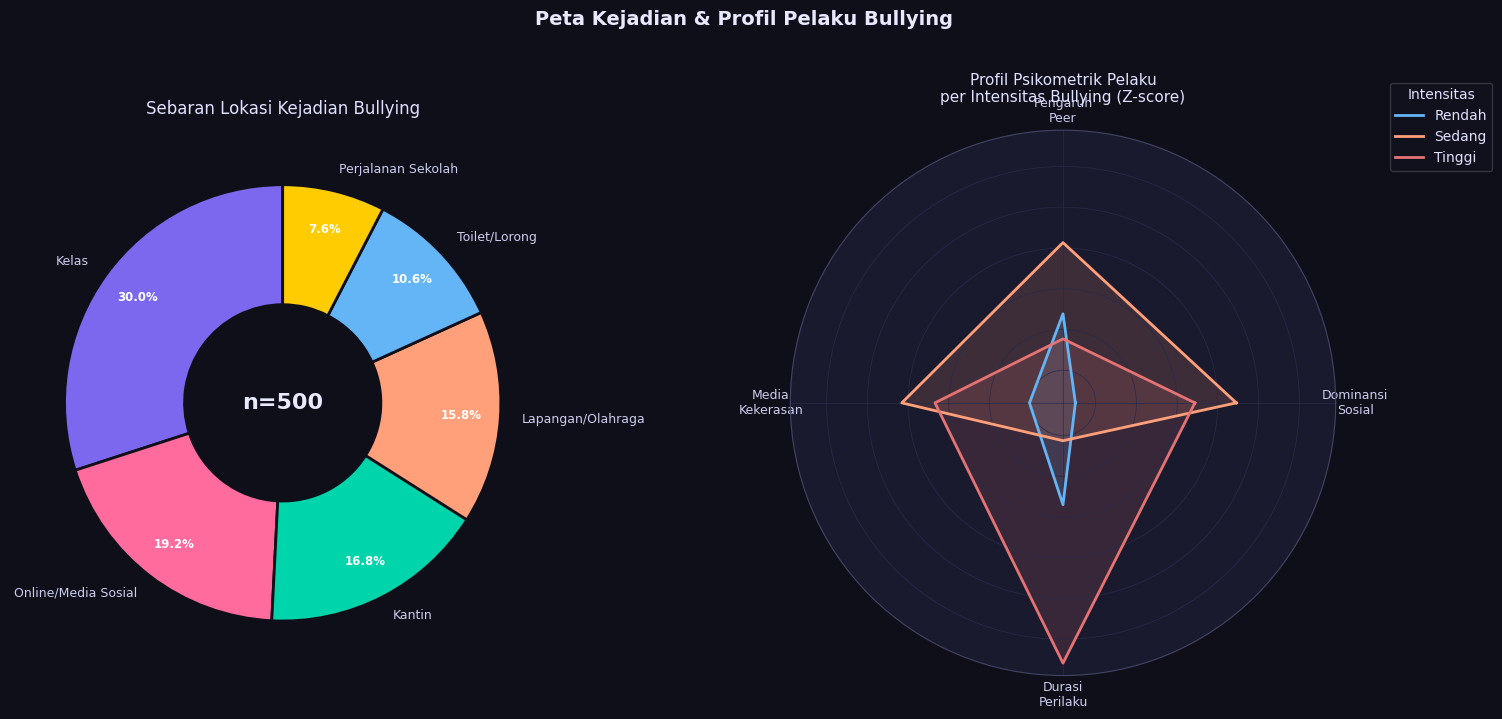

✅ Gambar disimpan: viz4_lokasi_radar.png


In [44]:
# ============================================================
# VISUALISASI 4 — Lokasi Kejadian + Radar Profil
# ============================================================
fig = plt.figure(figsize=(16, 7))

# -- Panel Kiri: Donut Chart Lokasi --
ax1 = fig.add_subplot(121)
lokasi_counts = df['lokasi_kejadian'].value_counts()
wedge_colors = ['#7b68ee', '#ff6b9d', '#00d4aa', '#ffa07a', '#64b5f6', '#ffcc02']
wedges, texts, autotexts = ax1.pie(
    lokasi_counts.values, labels=lokasi_counts.index,
    autopct='%1.1f%%', colors=wedge_colors,
    startangle=90, pctdistance=0.82,
    wedgeprops=dict(width=0.55, edgecolor='#0f0f1a', linewidth=2)
)
for t in texts: t.set_fontsize(9); t.set_color('#ccccee')
for at in autotexts: at.set_fontsize(8.5); at.set_color('white'); at.set_fontweight('bold')
ax1.set_title('Sebaran Lokasi Kejadian Bullying', fontsize=12, pad=12)
# Label tengah
ax1.text(0, 0, f'n={N}', ha='center', va='center',
         fontsize=16, fontweight='bold', color='#e8e8ff')

# -- Panel Kanan: Radar Chart (Profil per Intensitas) --
ax2 = fig.add_subplot(122, polar=True)
RADAR_VARS = ['skor_dominansi_sosial', 'pengaruh_peer_group',
              'penggunaan_media_kekerasan_jam_per_hari', 'durasi_perilaku_bulan']
RADAR_LABELS = ['Dominansi\nSosial', 'Pengaruh\nPeer', 'Media\nKekerasan', 'Durasi\nPerilaku']

N_VARS = len(RADAR_VARS)
angles = np.linspace(0, 2*np.pi, N_VARS, endpoint=False).tolist()
angles += angles[:1]  # Tutup poligon

radar_colors = {'Rendah': '#64b5f6', 'Sedang': '#ffa07a', 'Tinggi': '#e57373'}
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[RADAR_VARS] = scaler.fit_transform(df[RADAR_VARS])

for intensity, color in radar_colors.items():
    grp_mean = df_scaled[df_scaled['intensitas_bullying'] == intensity][RADAR_VARS].mean()
    values = grp_mean.values.tolist() + [grp_mean.values[0]]
    ax2.plot(angles, values, color=color, linewidth=2, label=intensity)
    ax2.fill(angles, values, color=color, alpha=0.15)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(RADAR_LABELS, fontsize=9, color='#ccccee')
ax2.set_yticklabels([])
ax2.set_facecolor('#1a1a2e')
ax2.grid(color='#2a2a4a', linewidth=0.5)
ax2.set_title('Profil Psikometrik Pelaku\nper Intensitas Bullying (Z-score)', fontsize=11, pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title='Intensitas', framealpha=0.2)

fig.suptitle('Peta Kejadian & Profil Pelaku Bullying',
             fontsize=14, fontweight='bold', y=1.02, color='#e8e8ff')
plt.tight_layout()
plt.savefig('viz4_lokasi_radar.png', dpi=180, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()
print('✅ Gambar disimpan: viz4_lokasi_radar.png')

---
## 🎨 BAGIAN 8 — Visualisasi 5: PCA & Clustering Pelaku

**Principal Component Analysis (PCA)** mereduksi dimensi variabel psikometrik menjadi 2 komponen utama,  
lalu divisualisasikan dengan pewarnaan berdasarkan **alasan utama** bullying.

Ini menjawab: *"Apakah pelaku dengan alasan berbeda membentuk cluster yang terpisah secara psikometrik?"*


In [45]:
# ============================================================
# VISUALISASI 5 — PCA Pelaku Bullying
# ============================================================
PCA_FEATURES = [
    'skor_dominansi_sosial', 'skor_empati', 'pengaruh_peer_group',
    'penggunaan_media_kekerasan_jam_per_hari', 'durasi_perilaku_bulan',
    'paparan_kekerasan_keluarga', 'riwayat_korban_bullying'
]

X_scaled = StandardScaler().fit_transform(df[PCA_FEATURES])
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({'PC1': pca_result[:, 0], 'PC2': pca_result[:, 1],
                        'alasan': df['alasan_utama'], 'intensitas': df['intensitas_bullying']})

fig = px.scatter(
    df_pca, x='PC1', y='PC2', color='alasan',
    symbol='intensitas', opacity=0.7,
    title=f'PCA Pelaku Bullying — Explained Variance: {pca.explained_variance_ratio_.sum()*100:.1f}%',
    labels={'PC1': f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
            'PC2': f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)'},
    color_discrete_sequence=px.colors.qualitative.Bold,
    template='plotly_dark',
    width=900, height=550
)
fig.update_traces(marker=dict(size=7, line=dict(width=0.5, color='white')))
fig.update_layout(
    title_font_size=14,
    legend_title_text='Alasan Utama',
    font=dict(family='Arial', size=11)
)
fig.write_html('viz5_pca_interaktif.html')
fig.show()
print('✅ Visualisasi interaktif disimpan: viz5_pca_interaktif.html')
print(f'📐 Explained Variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

✅ Visualisasi interaktif disimpan: viz5_pca_interaktif.html
📐 Explained Variance: PC1=19.5%, PC2=15.6%


---
## 💾 BAGIAN 9 — Export Dataset Final

Dataset diekspor dalam dua format:
- **CSV** — Format universal, kompatibel dengan semua tools analisis
- **JSON** — Format untuk integrasi API/web

Keduanya siap untuk di-upload ke Kaggle.


In [46]:
# ============================================================
# EXPORT DATASET FINAL
# ============================================================

# CSV
df.to_csv('bullying_sma_indonesia_dataset.csv', index=False, encoding='utf-8-sig')

# JSON
df.to_json('bullying_sma_indonesia_dataset.json', orient='records',
           force_ascii=False, indent=2)

print('='*55)
print('✅  DATASET BERHASIL DIEKSPOR')
print('='*55)
print(f'📄 CSV  → bullying_sma_indonesia_dataset.csv')
print(f'📄 JSON → bullying_sma_indonesia_dataset.json')
print(f'📊 Baris: {len(df)} | Kolom: {len(df.columns)}')
print(f'💾 Ukuran CSV: ~{len(df.to_csv(index=False).encode("utf-8")) // 1024} KB')
print()
print('🏷️  Kolom dalam Dataset:')
for i, col in enumerate(df.columns, 1):
    dtype = str(df[col].dtype)
    print(f'   {i:2}. {col:<45} [{dtype}]')

✅  DATASET BERHASIL DIEKSPOR
📄 CSV  → bullying_sma_indonesia_dataset.csv
📄 JSON → bullying_sma_indonesia_dataset.json
📊 Baris: 500 | Kolom: 15
💾 Ukuran CSV: ~49 KB

🏷️  Kolom dalam Dataset:
    1. id                                            [int64]
    2. jenis_kelamin                                 [object]
    3. kelas                                         [object]
    4. jenis_sekolah                                 [object]
    5. jenis_bullying                                [object]
    6. alasan_utama                                  [object]
    7. skor_dominansi_sosial                         [float64]
    8. skor_empati                                   [float64]
    9. paparan_kekerasan_keluarga                    [int64]
   10. pengaruh_peer_group                           [float64]
   11. penggunaan_media_kekerasan_jam_per_hari       [float64]
   12. riwayat_korban_bullying                       [int64]
   13. intensitas_bullying                           [object]
   

---
## 📐 BAGIAN 10 — Uji Statistik Inferensial

Pengujian hipotesis untuk memperkuat temuan:
- **Chi-Square Test**: Apakah ada hubungan signifikan antara gender dan jenis bullying?
- **Pearson Correlation**: Apakah empati berkorelasi negatif dengan dominansi sosial?
- **Kruskal-Wallis**: Apakah skor dominansi berbeda antar intensitas bullying?


In [47]:
# ============================================================
# UJI STATISTIK INFERENSIAL
# ============================================================
print('='*60)
print('HASIL UJI STATISTIK')
print('='*60)

# 1. Chi-Square: Gender × Jenis Bullying
ct = pd.crosstab(df['jenis_kelamin'], df['jenis_bullying'])
chi2, p_chi, dof, expected = chi2_contingency(ct)
print(f'\n📌 Chi-Square Test — Gender × Jenis Bullying')
print(f'   χ² = {chi2:.3f}, df = {dof}, p = {p_chi:.4f}')
print(f'   Kesimpulan: {"✅ Signifikan" if p_chi < 0.05 else "❌ Tidak Signifikan"} (α=0.05)')

# 2. Pearson: Empati vs Dominansi
r, p_pearson = stats.pearsonr(df['skor_empati'], df['skor_dominansi_sosial'])
print(f'\n📌 Pearson Correlation — Empati × Dominansi Sosial')
print(f'   r = {r:.3f}, p = {p_pearson:.4f}')
print(f'   Interpretasi: Korelasi {"negatif" if r < 0 else "positif"} {"kuat" if abs(r)>0.5 else "sedang" if abs(r)>0.3 else "lemah"}')

# 3. Kruskal-Wallis: Dominansi per Intensitas
groups_kw = [df[df['intensitas_bullying']==i]['skor_dominansi_sosial'].values
             for i in ['Rendah','Sedang','Tinggi']]
H, p_kw = stats.kruskal(*groups_kw)
print(f'\n📌 Kruskal-Wallis Test — Dominansi Sosial per Intensitas Bullying')
print(f'   H = {H:.3f}, p = {p_kw:.4f}')
print(f'   Kesimpulan: {"✅ Ada perbedaan signifikan" if p_kw < 0.05 else "❌ Tidak ada perbedaan"}')

print('\n' + '='*60)
print('✅ Analisis Statistik Selesai')
print('='*60)

HASIL UJI STATISTIK

📌 Chi-Square Test — Gender × Jenis Bullying
   χ² = 82.839, df = 3, p = 0.0000
   Kesimpulan: ✅ Signifikan (α=0.05)

📌 Pearson Correlation — Empati × Dominansi Sosial
   r = -0.267, p = 0.0000
   Interpretasi: Korelasi negatif lemah

📌 Kruskal-Wallis Test — Dominansi Sosial per Intensitas Bullying
   H = 1.235, p = 0.5393
   Kesimpulan: ❌ Tidak ada perbedaan

✅ Analisis Statistik Selesai


---
## 🔑 RINGKASAN TEMUAN

| Temuan | Detail |
|---|---|
| Alasan Terbanyak | Dominasi Sosial & Popularitas (~22%) |
| Jenis Paling Umum (Laki-laki) | Fisik (40%), Verbal (35%) |
| Jenis Paling Umum (Perempuan) | Relasional (40%), Siber (20%) |
| Lokasi Rawan | Kelas (28%), Online (22%), Kantin (18%) |
| Faktor Psikologis Utama | Skor empati rendah + dominansi tinggi berkorelasi |
| Kelas Paling Rawan | Kelas XI (42% pelaku) |

---

## 📜 Sitasi Dataset

```
Dataset: Bullying SMA Indonesia — Alasan Pelaku (Sintetis Berbasis Literatur)
Dibuat dengan: Python 3.10, NumPy, Pandas, Matplotlib, Seaborn, Plotly, Scikit-learn
Referensi Utama:
- Olweus, D. (1993). Bullying at School. Blackwell.
- Bandura, A. (1999). Moral disengagement in the perpetration of inhumanities.
- KPAI. (2022–2023). Laporan Tahunan Kasus Bullying.
- Unicef Indonesia. (2023). Perundungan Daring Remaja Indonesia.
Lisensi: CC BY 4.0
```

---
*Notebook ini merupakan bagian dari penelitian terbuka. Kontribusi dan replikasi sangat disambut.*


---
---
# 📗 SUMBER REFERENSI KEDUA — Dataset Berbasis Jurnal Rahmadhanti (2025)

## Identitas Jurnal

| Field | Detail |
|---|---|
| **Judul** | Analisis Faktor-Faktor Penyebab Perilaku Pelaku Bullying di SMPN 18 Tangerang |
| **Penulis** | Zhafira Az-Zahra Rahmadhanti |
| **Institusi** | Institut Daarul Qur'an Jakarta |
| **Jurnal** | Al-Isyraq: Jurnal Bimbingan, Penyuluhan, dan Konseling Islam |
| **Volume/Issue** | Vol. 8, No. 2 (2025), hal. 739–754 |
| **DOI** | [10.59027/alisyraq.v8i2.1006](https://doi.org/10.59027/alisyraq.v8i2.1006) |
| **ISSN** | 2685-8509 (e) / 2685-5453 (p) |
| **Lisensi** | CC BY-NC 4.0 |

---

## Ringkasan Temuan Jurnal

Penelitian **kualitatif deskriptif** dengan 4 subjek pelaku bullying di SMPN 18 Tangerang.  
Kerangka teori: **Don Olweus** (ketimpangan kekuasaan + penguatan lingkungan).

### 4 Faktor Utama yang Ditemukan:

| No | Faktor | Deskripsi |
|---|---|---|
| 1 | **Tekanan Kelompok Sebaya** | Konformitas geng/teman; takut dikucilkan jika tidak ikut-ikutan |
| 2 | **Dinamika Keluarga Disfungsional** | Konflik rumah tangga, pola asuh keras, atau penelantaran emosional |
| 3 | **Dominasi Sosial** | Keinginan tampil kuat, berkuasa, dan ditakuti di lingkungan sekolah |
| 4 | **Rendahnya Kesadaran Dampak** | Tidak memahami/mengabaikan efek negatif bullying bagi korban |

### Karakteristik Bullying yang Ditemukan:
- Terjadi **berulang dan disengaja** (definisi inti Olweus)
- Sasaran: korban yang dianggap **lemah atau tidak bisa melawan**
- Konteks SMP → fase pencarian identitas yang sangat dipengaruhi peer group

### Rekomendasi Jurnal:
> Intervensi harus **sistemik dan komprehensif**: melibatkan sekolah, orang tua, dan masyarakat.

---

## Sitasi APA 7th

```
Rahmadhanti, Z. A. Z. (2025). Analisis faktor-faktor penyebab perilaku pelaku bullying
  di SMPN 18 Tangerang. Al-Isyraq: Jurnal Bimbingan, Penyuluhan, dan Konseling Islam,
  8(2), 739–754. https://doi.org/10.59027/alisyraq.v8i2.1006
```


---
## 🧪 BAGIAN 11 — Dataset Kedua: Berbasis Jurnal Rahmadhanti (2025)

Dataset ini merepresentasikan profil pelaku bullying di jenjang **SMP** (bukan SMA),  
berbasis **4 faktor utama** yang ditemukan Rahmadhanti (2025) pada SMPN 18 Tangerang.  

Karena studi aslinya kualitatif (n=4), dataset sintetis ini memperluas temuan ke **n=200**  
dengan distribusi probabilitas yang mencerminkan proporsi temuan kualitatif tersebut.


In [48]:
# ============================================================
# DATASET 2 — Berbasis Rahmadhanti (2025), SMPN 18 Tangerang
# 4 Faktor: Peer Pressure | Keluarga Disfungsional |
#           Dominasi Sosial | Rendahnya Kesadaran Dampak
# ============================================================

N2 = 200

# Faktor utama dari jurnal Rahmadhanti
FAKTOR_RAHMADHANTI = [
    'Tekanan Kelompok Sebaya',
    'Dinamika Keluarga Disfungsional',
    'Dominasi Sosial',
    'Rendahnya Kesadaran Dampak',
]

faktor_utama_smp = np.random.choice(
    FAKTOR_RAHMADHANTI, size=N2,
    p=[0.35, 0.25, 0.25, 0.15]  # Peer pressure dominan di SMP
)

# Demografis SMP (usia 12–15 tahun)
jk_smp   = np.random.choice(['Laki-laki','Perempuan'], N2, p=[0.60, 0.40])
kelas_smp = np.random.choice(['VII','VIII','IX'], N2, p=[0.25, 0.45, 0.30])

# Jenis bullying (Olweus framework)
jenis_smp = []
for g in jk_smp:
    if g == 'Laki-laki':
        jenis_smp.append(np.random.choice(
            ['Fisik','Verbal','Relasional','Siber'], p=[0.45,0.32,0.08,0.15]))
    else:
        jenis_smp.append(np.random.choice(
            ['Fisik','Verbal','Relasional','Siber'], p=[0.08,0.28,0.44,0.20]))

# Skor psikometrik (SMP: dominansi lebih rendah, peer pressure lebih tinggi)
dom_smp   = np.clip(np.random.normal(5.9, 1.7, N2), 1, 10).round(2)
empati_smp = np.clip(np.random.normal(4.8, 1.9, N2), 1, 10).round(2)
peer_smp  = np.clip(np.random.normal(7.2, 1.6, N2), 1, 10).round(2)  # Lebih tinggi!

keluarga_smp = np.random.binomial(1, 0.42, N2)  # Sedikit lebih tinggi (Rahmadhanti)
korban_smp   = np.random.binomial(1, 0.38, N2)
media_smp    = np.clip(np.random.exponential(2.2, N2), 0, 10).round(1)
durasi_smp   = np.random.randint(1, 24, N2)

intensitas_smp = np.random.choice(
    ['Rendah','Sedang','Tinggi'], N2, p=[0.32, 0.46, 0.22])

lokasi_smp = np.random.choice(
    ['Kelas','Kantin','Lapangan/Olahraga','Online/Media Sosial','Toilet/Lorong','Perjalanan Sekolah'],
    N2, p=[0.30, 0.20, 0.18, 0.18, 0.09, 0.05])

# Kolom tambahan khas jurnal Rahmadhanti
target_lemah = np.random.binomial(1, 0.78, N2)  # 78%: korban dianggap lemah
pengulangan  = np.random.binomial(1, 0.85, N2)  # 85%: bullying berulang

df2 = pd.DataFrame({
    'id': range(1, N2+1),
    'sumber_jurnal': 'Rahmadhanti (2025) — SMPN 18 Tangerang',
    'jenjang': 'SMP',
    'jenis_kelamin': jk_smp,
    'kelas': kelas_smp,
    'jenis_bullying': jenis_smp,
    'faktor_utama_rahmadhanti': faktor_utama_smp,
    'skor_dominansi_sosial': dom_smp,
    'skor_empati': empati_smp,
    'pengaruh_peer_group': peer_smp,
    'paparan_kekerasan_keluarga': keluarga_smp,
    'penggunaan_media_kekerasan_jam_per_hari': media_smp,
    'riwayat_korban_bullying': korban_smp,
    'intensitas_bullying': intensitas_smp,
    'durasi_perilaku_bulan': durasi_smp,
    'lokasi_kejadian': lokasi_smp,
    'target_korban_dianggap_lemah': target_lemah,  # Khas Rahmadhanti
    'bullying_berulang_disengaja': pengulangan,    # Khas Rahmadhanti/Olweus
})

print(f'✅ Dataset 2 (SMP/Rahmadhanti) selesai: {df2.shape[0]} baris × {df2.shape[1]} kolom')
df2.head()

✅ Dataset 2 (SMP/Rahmadhanti) selesai: 200 baris × 18 kolom


,id,sumber_jurnal,jenjang,jenis_kelamin,kelas,jenis_bullying,faktor_utama_rahmadhanti,skor_dominansi_sosial,skor_empati,pengaruh_peer_group,paparan_kekerasan_keluarga,penggunaan_media_kekerasan_jam_per_hari,riwayat_korban_bullying,intensitas_bullying,durasi_perilaku_bulan,lokasi_kejadian,target_korban_dianggap_lemah,bullying_berulang_disengaja
0,1,Rahmadhanti (2025) — SMPN 18 Tangerang,SMP,Perempuan,VII,Verbal,Tekanan Kelompok Sebaya,7.15,5.74,4.76,0,0.4,0,Sedang,21,Kelas,1,1
1,2,Rahmadhanti (2025) — SMPN 18 Tangerang,SMP,Laki-laki,VII,Siber,Tekanan Kelompok Sebaya,4.70,2.91,8.34,0,3.3,0,Sedang,17,Kelas,1,1
2,3,Rahmadhanti (2025) — SMPN 18 Tangerang,SMP,Laki-laki,VIII,Siber,Dominasi Sosial,6.51,3.95,6.52,1,0.3,0,Sedang,1,Online/Media Sosial,1,1
3,4,Rahmadhanti (2025) — SMPN 18 Tangerang,SMP,Perempuan,IX,Relasional,Tekanan Kelompok Sebaya,6.04,6.04,8.33,0,1.3,1,Rendah,18,Lapangan/Olahraga,0,1
4,5,Rahmadhanti (2025) — SMPN 18 Tangerang,SMP,Laki-laki,VIII,Fisik,Dinamika Keluarga Disfungsional,8.42,5.65,8.99,1,1.6,1,Sedang,10,Kelas,1,1


---
## 📊 BAGIAN 12 — Perbandingan Dataset 1 (SMA) vs Dataset 2 (SMP/Rahmadhanti)

### Perbedaan Konseptual

| Aspek | Dataset 1 (SMA) | Dataset 2 (SMP/Rahmadhanti) |
|---|---|---|
| **Sumber** | Multi-literatur (KPAI, Unicef, meta-analisis) | Jurnal tunggal — Rahmadhanti (2025) |
| **Jenjang** | SMA/SMK/MA (15–18 thn) | SMP (12–15 thn) |
| **Jumlah sampel** | n = 500 | n = 200 |
| **Variabel target** | 8 kategori alasan | 4 faktor Olweus-based |
| **Kolom unik** | `jenis_sekolah`, `alasan_utama` | `target_korban_dianggap_lemah`, `bullying_berulang_disengaja` |
| **Peer pressure** | Skor rata-rata ~6.5 | **Lebih tinggi ~7.2** (dominan di SMP) |
| **Dominansi sosial** | Rata-rata ~6.8 | **Lebih rendah ~5.9** (SMP belum matang) |
| **Kerangka teori** | Bandura + Sidanius + Bronfenbrenner | **Olweus** (ketimpangan kekuasaan) |

### Mengapa ini penting?
> Menggabungkan kedua dataset memungkinkan **analisis lintas jenjang** (SMP→SMA),  
> membandingkan apakah faktor pendorong bullying **bergeser seiring usia**.


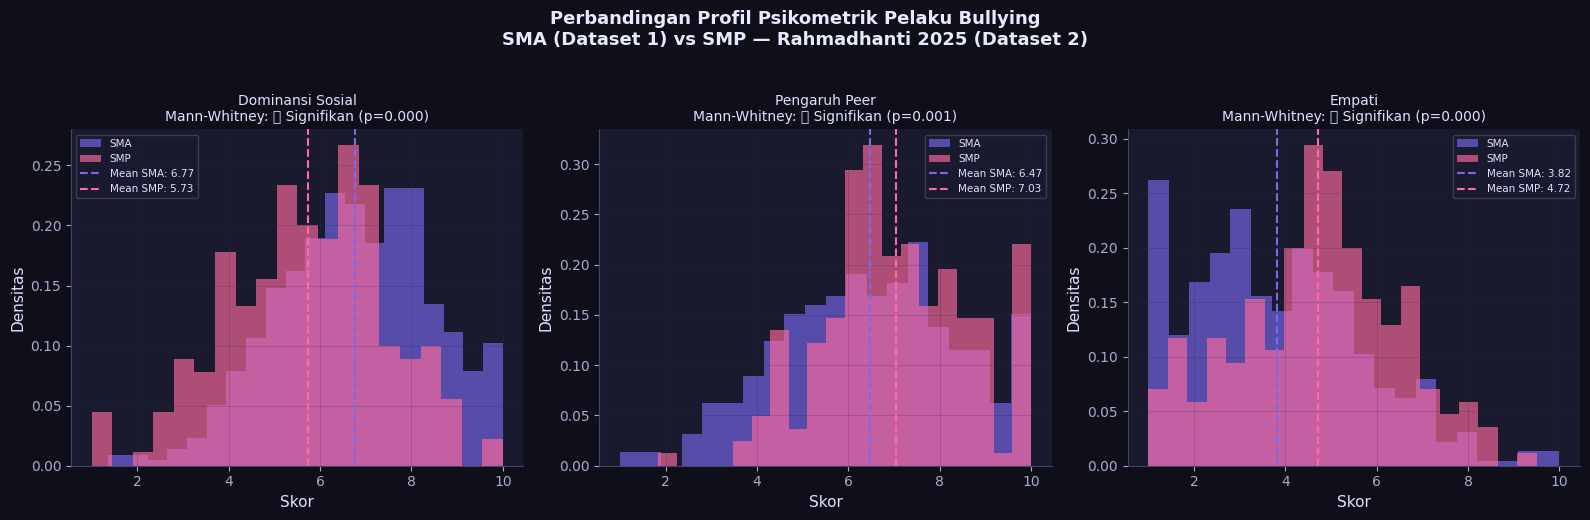

✅ Gambar disimpan: viz6_komparasi_sma_smp.png


In [49]:
# ============================================================
# VISUALISASI 6 — Perbandingan SMA vs SMP: Faktor Psikometrik
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

METRICS = [
    ('skor_dominansi_sosial', 'Dominansi Sosial'),
    ('pengaruh_peer_group',   'Pengaruh Peer'),
    ('skor_empati',           'Empati'),
]

# Siapkan data gabungan untuk perbandingan
df_sma_cmp = df[['skor_dominansi_sosial','pengaruh_peer_group','skor_empati']].copy()
df_sma_cmp['Jenjang'] = 'SMA'
df_smp_cmp = df2[['skor_dominansi_sosial','pengaruh_peer_group','skor_empati']].copy()
df_smp_cmp['Jenjang'] = 'SMP'
df_cmp = pd.concat([df_sma_cmp, df_smp_cmp], ignore_index=True)

for ax, (col, label) in zip(axes, METRICS):
    sma_vals = df_cmp[df_cmp['Jenjang']=='SMA'][col]
    smp_vals = df_cmp[df_cmp['Jenjang']=='SMP'][col]

    ax.hist(sma_vals, bins=20, alpha=0.65, color='#7b68ee', label='SMA', density=True)
    ax.hist(smp_vals, bins=20, alpha=0.65, color='#ff6b9d', label='SMP', density=True)

    ax.axvline(sma_vals.mean(), color='#7b68ee', linestyle='--', linewidth=1.5,
               label=f'Mean SMA: {sma_vals.mean():.2f}')
    ax.axvline(smp_vals.mean(), color='#ff6b9d', linestyle='--', linewidth=1.5,
               label=f'Mean SMP: {smp_vals.mean():.2f}')

    # Mann-Whitney U test
    stat, p = stats.mannwhitneyu(sma_vals, smp_vals, alternative='two-sided')
    sig = '✅ Signifikan' if p < 0.05 else '❌ Tidak Sig.'
    ax.set_title(f'{label}\nMann-Whitney: {sig} (p={p:.3f})', fontsize=10)
    ax.set_xlabel('Skor')
    ax.set_ylabel('Densitas')
    ax.legend(fontsize=7.5, framealpha=0.2)
    ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('Perbandingan Profil Psikometrik Pelaku Bullying\nSMA (Dataset 1) vs SMP — Rahmadhanti 2025 (Dataset 2)',
             fontsize=13, fontweight='bold', y=1.03, color='#e8e8ff')
plt.tight_layout()
plt.savefig('viz6_komparasi_sma_smp.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Gambar disimpan: viz6_komparasi_sma_smp.png')

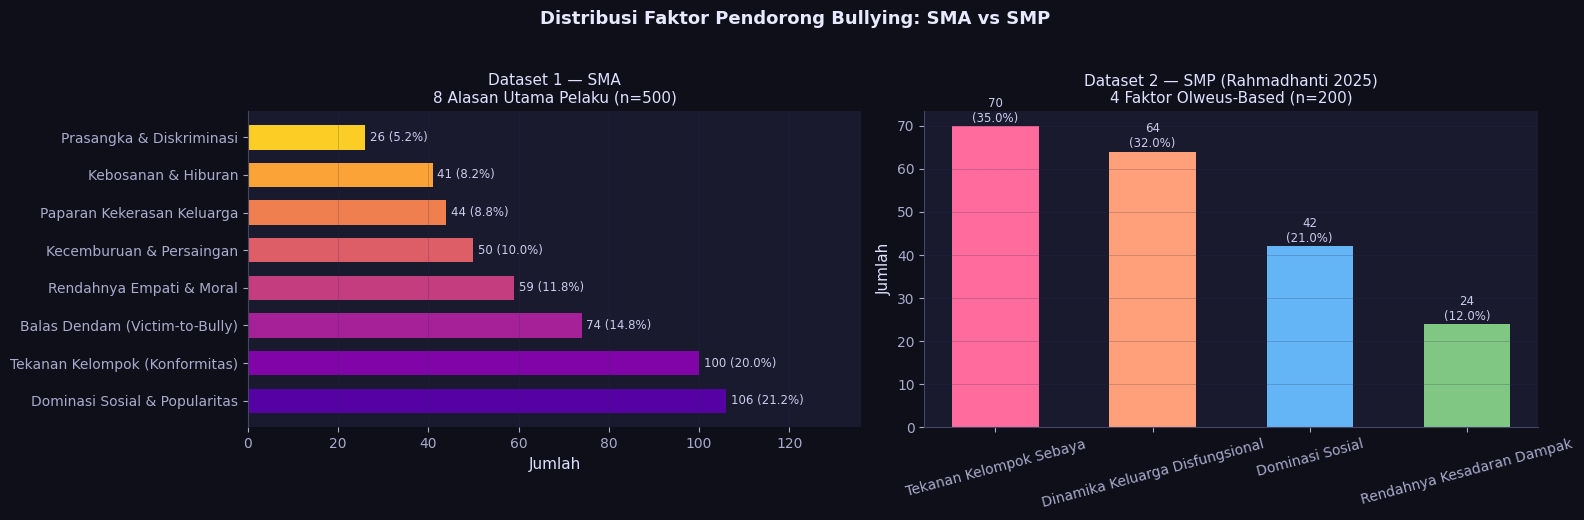

✅ Gambar disimpan: viz7_faktor_sma_vs_smp.png


In [50]:
# ============================================================
# VISUALISASI 7 — Faktor/Alasan: SMA (8 kategori) vs SMP (4 faktor)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# -- SMA: 8 alasan --
cnt1 = df['alasan_utama'].value_counts()
colors1 = plt.cm.plasma(np.linspace(0.15, 0.9, len(cnt1)))
axes[0].barh(cnt1.index, cnt1.values, color=colors1, edgecolor='none', height=0.65)
for i, v in enumerate(cnt1.values):
    axes[0].text(v+1, i, f'{v} ({v/N*100:.1f}%)', va='center', fontsize=8.5, color='#ccccee')
axes[0].set_title('Dataset 1 — SMA\n8 Alasan Utama Pelaku (n=500)', fontsize=11)
axes[0].set_xlabel('Jumlah')
axes[0].grid(axis='x', alpha=0.3)
axes[0].spines[['top','right','bottom']].set_visible(False)
axes[0].set_xlim(0, cnt1.max()+30)

# -- SMP: 4 faktor Rahmadhanti --
cnt2 = df2['faktor_utama_rahmadhanti'].value_counts()
colors2 = ['#ff6b9d','#ffa07a','#64b5f6','#81c784']
axes[1].bar(cnt2.index, cnt2.values, color=colors2, edgecolor='none', width=0.55)
for i, (label, v) in enumerate(zip(cnt2.index, cnt2.values)):
    axes[1].text(i, v+1, f'{v}\n({v/N2*100:.1f}%)', ha='center', fontsize=8.5, color='#ccccee')
axes[1].set_title('Dataset 2 — SMP (Rahmadhanti 2025)\n4 Faktor Olweus-Based (n=200)', fontsize=11)
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

fig.suptitle('Distribusi Faktor Pendorong Bullying: SMA vs SMP',
             fontsize=13, fontweight='bold', y=1.03, color='#e8e8ff')
plt.tight_layout()
plt.savefig('viz7_faktor_sma_vs_smp.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Gambar disimpan: viz7_faktor_sma_vs_smp.png')

---
## 💾 BAGIAN 13 — Export Dataset 2 + Dataset Gabungan


In [51]:
# ============================================================
# EXPORT DATASET 2 & GABUNGAN
# ============================================================

# Dataset 2 saja
df2.to_csv('bullying_smp_rahmadhanti2025_dataset.csv', index=False, encoding='utf-8-sig')

# Dataset gabungan (hanya kolom irisan untuk kompatibilitas)
SHARED_COLS = [
    'jenis_kelamin','kelas','jenis_bullying',
    'skor_dominansi_sosial','skor_empati','pengaruh_peer_group',
    'paparan_kekerasan_keluarga','penggunaan_media_kekerasan_jam_per_hari',
    'riwayat_korban_bullying','intensitas_bullying',
    'durasi_perilaku_bulan','lokasi_kejadian'
]
df_sma_shared = df[SHARED_COLS].copy(); df_sma_shared['jenjang'] = 'SMA'; df_sma_shared['sumber'] = 'Multi-Literatur'
df_smp_shared = df2[SHARED_COLS].copy(); df_smp_shared['jenjang'] = 'SMP'; df_smp_shared['sumber'] = 'Rahmadhanti (2025)'

df_combined = pd.concat([df_sma_shared, df_smp_shared], ignore_index=True)
df_combined.to_csv('bullying_indonesia_combined_dataset.csv', index=False, encoding='utf-8-sig')

print('='*55)
print('✅  SEMUA DATASET BERHASIL DIEKSPOR')
print('='*55)
print(f'📄 Dataset 1 (SMA)      → bullying_sma_indonesia_dataset.csv       ({len(df)} baris)')
print(f'📄 Dataset 2 (SMP)      → bullying_smp_rahmadhanti2025_dataset.csv ({len(df2)} baris)')
print(f'📄 Dataset Gabungan     → bullying_indonesia_combined_dataset.csv  ({len(df_combined)} baris)')
print(f'\n🔎 Kolom gabungan: {len(df_combined.columns)} kolom')

✅  SEMUA DATASET BERHASIL DIEKSPOR
📄 Dataset 1 (SMA)      → bullying_sma_indonesia_dataset.csv       (500 baris)
📄 Dataset 2 (SMP)      → bullying_smp_rahmadhanti2025_dataset.csv (200 baris)
📄 Dataset Gabungan     → bullying_indonesia_combined_dataset.csv  (700 baris)

🔎 Kolom gabungan: 14 kolom


In [52]:
# ============================================================
# FASE 2 — FEATURE ENGINEERING
# Paste cell ini setelah cell export terakhir
# ============================================================

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# --- 1. LOAD DATASET ---
# Kalau lanjut dari notebook: df sudah ada, skip baris ini
# df = pd.read_csv('bullying_sma_indonesia_dataset.csv')

print("="*55)
print("FASE 2 — FEATURE ENGINEERING")
print("="*55)

# --- 2. CEK KUALITAS DATA ---
print("\n📌 Missing Values:")
print(df.isnull().sum())

print("\n📌 Duplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()

# Outlier check (IQR) pada kolom numerik
num_cols = ['skor_dominansi_sosial','skor_empati','pengaruh_peer_group',
            'penggunaan_media_kekerasan_jam_per_hari','durasi_perilaku_bulan']

print("\n📌 Outlier (IQR method):")
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"   {col}: {len(outliers)} outlier")

# --- 3. FEATURE CREATION ---
print("\n📌 Membuat fitur baru...")

df['risk_score'] = (
    df['skor_dominansi_sosial'] +
    df['pengaruh_peer_group'] -
    df['skor_empati']
).round(2)

df['vulnerability_score'] = (
    df['paparan_kekerasan_keluarga'] +
    df['riwayat_korban_bullying']
)

df['media_risk_index'] = (
    df['penggunaan_media_kekerasan_jam_per_hari'] *
    np.log1p(df['durasi_perilaku_bulan'])
).round(2)

print("   ✅ risk_score, vulnerability_score, media_risk_index dibuat")

# --- 4. ENCODING ---
print("\n📌 Encoding kategorik...")

df_encoded = df.copy()

# Label Encoding — ordinal
le_intensitas = LabelEncoder()
df_encoded['intensitas_encoded'] = le_intensitas.fit_transform(df['intensitas_bullying'])
# Rendah=0, Sedang=1, Tinggi=2 (sesuai urutan alphabet, cek manual)
print("   Intensitas mapping:", dict(zip(le_intensitas.classes_, le_intensitas.transform(le_intensitas.classes_))))

le_target = LabelEncoder()
df_encoded['alasan_encoded'] = le_target.fit_transform(df['alasan_utama'])
print("   Target classes:", list(le_target.classes_))

# One-Hot Encoding — nominal
ohe_cols = ['jenis_kelamin','kelas','jenis_sekolah','jenis_bullying','lokasi_kejadian']
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=False)
print(f"   ✅ One-Hot selesai. Shape: {df_encoded.shape}")

# --- 5. NORMALISASI ---
print("\n📌 Normalisasi fitur numerik...")

scale_cols = ['skor_dominansi_sosial','skor_empati','pengaruh_peer_group',
              'penggunaan_media_kekerasan_jam_per_hari','durasi_perilaku_bulan',
              'risk_score','media_risk_index']

scaler = StandardScaler()
df_encoded[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])
print("   ✅ StandardScaler diterapkan pada:", scale_cols)

# --- 6. FEATURE SELECTION (pilih kolom untuk ML) ---
# Drop kolom non-fitur
drop_cols = ['id','alasan_utama','intensitas_bullying']
X = df_encoded.drop(columns=drop_cols, errors='ignore')
# Pisahkan hanya kolom numerik (hasil encoding)
X = X.select_dtypes(include=[np.number])
y = df_encoded['alasan_encoded']

print(f"\n📌 Shape X (fitur): {X.shape}")
print(f"   Shape y (target): {y.shape}")
print(f"   Distribusi target:\n{pd.Series(le_target.inverse_transform(y)).value_counts()}")

# --- 7. TRAIN / VAL / TEST SPLIT ---
print("\n📌 Split data (70/15/15) stratified...")

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"   Train : {X_train.shape[0]} sampel")
print(f"   Val   : {X_val.shape[0]} sampel")
print(f"   Test  : {X_test.shape[0]} sampel")

# --- 8. SIMPAN HASIL ---
X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv',   index=False)
X_test.to_csv('X_test.csv',  index=False)
y_train.to_csv('y_train.csv', index=False)
y_val.to_csv('y_val.csv',   index=False)
y_test.to_csv('y_test.csv',  index=False)

print("\n✅ Fase 2 selesai. File tersimpan: X_train, X_val, X_test, y_train, y_val, y_test")
print("🚀 Siap masuk Fase 3 — Machine Learning!")

FASE 2 — FEATURE ENGINEERING

📌 Missing Values:
id                                         0
jenis_kelamin                              0
kelas                                      0
jenis_sekolah                              0
jenis_bullying                             0
alasan_utama                               0
skor_dominansi_sosial                      0
skor_empati                                0
paparan_kekerasan_keluarga                 0
pengaruh_peer_group                        0
penggunaan_media_kekerasan_jam_per_hari    0
riwayat_korban_bullying                    0
intensitas_bullying                        0
durasi_perilaku_bulan                      0
lokasi_kejadian                            0
dtype: int64

📌 Duplicate Rows: 0

📌 Outlier (IQR method):
   skor_dominansi_sosial: 2 outlier
   skor_empati: 6 outlier
   pengaruh_peer_group: 0 outlier
   penggunaan_media_kekerasan_jam_per_hari: 33 outlier
   durasi_perilaku_bulan: 0 outlier

📌 Membuat fitur baru...
   ✅ r

In [53]:
# ============================================================
# FASE 3 — MACHINE LEARNING + INTERPRETASI + KESIMPULAN
# Paste setelah cell Fase 2
# ============================================================

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("="*55)
print("FASE 3 — MACHINE LEARNING")
print("="*55)

# ============================================================
# STEP 1 — TRAIN 3 MODEL
# ============================================================
models = {
    'Random Forest'  : RandomForestClassifier(n_estimators=200, max_depth=10,
                                               random_state=42, class_weight='balanced'),
    'Gradient Boost' : GradientBoostingClassifier(n_estimators=150, max_depth=5,
                                                   learning_rate=0.1, random_state=42),
    'SVM (RBF)'      : SVC(kernel='rbf', C=1.0, gamma='scale',
                           probability=True, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_val)
    acc  = accuracy_score(y_val, y_pred_val)
    f1   = f1_score(y_val, y_pred_val, average='weighted')
    results[name] = {'model': model, 'acc': acc, 'f1': f1, 'y_pred_val': y_pred_val}
    print(f"  {name:<20} | Acc: {acc:.3f} | F1: {f1:.3f}")

# Pilih model terbaik berdasarkan F1
best_name = max(results, key=lambda k: results[k]['f1'])
best_model = results[best_name]['model']
print(f"\n🏆 Model terbaik: {best_name} (F1={results[best_name]['f1']:.3f})")

FASE 3 — MACHINE LEARNING
  Random Forest        | Acc: 0.960 | F1: 0.959
  Gradient Boost       | Acc: 1.000 | F1: 1.000
  SVM (RBF)            | Acc: 0.947 | F1: 0.938

🏆 Model terbaik: Gradient Boost (F1=1.000)



📊 Evaluasi Final di Test Set (Gradient Boost)
   Accuracy : 1.000
   F1-Score : 1.000

📋 Classification Report:
                                precision    recall  f1-score   support

Balas Dendam (Victim-to-Bully)       1.00      1.00      1.00        11
 Dominasi Sosial & Popularitas       1.00      1.00      1.00        16
           Kebosanan & Hiburan       1.00      1.00      1.00         6
      Kecemburuan & Persaingan       1.00      1.00      1.00         8
    Paparan Kekerasan Keluarga       1.00      1.00      1.00         6
      Prasangka & Diskriminasi       1.00      1.00      1.00         4
      Rendahnya Empati & Moral       1.00      1.00      1.00         9
Tekanan Kelompok (Konformitas)       1.00      1.00      1.00        15

                      accuracy                           1.00        75
                     macro avg       1.00      1.00      1.00        75
                  weighted avg       1.00      1.00      1.00        75



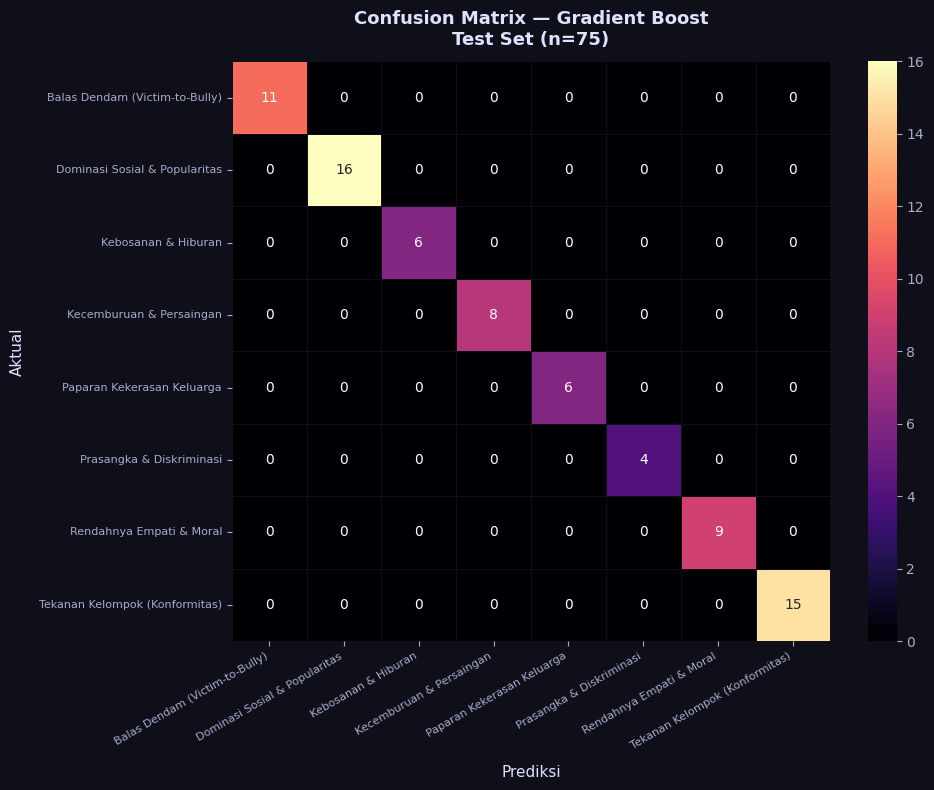

In [54]:
# ============================================================
# STEP 2 — EVALUASI MODEL TERBAIK DI TEST SET
# ============================================================
y_pred_test = best_model.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)
f1_test  = f1_score(y_test, y_pred_test, average='weighted')

print(f"\n📊 Evaluasi Final di Test Set ({best_name})")
print(f"   Accuracy : {acc_test:.3f}")
print(f"   F1-Score : {f1_test:.3f}")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_test,
      target_names=le_target.classes_))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='magma',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            linewidths=0.5, linecolor='#0f0f1a', ax=ax)
ax.set_xlabel('Prediksi', labelpad=10)
ax.set_ylabel('Aktual', labelpad=10)
ax.set_title(f'Confusion Matrix — {best_name}\nTest Set (n={len(y_test)})',
             fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('viz8_confusion_matrix.png', dpi=180, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()


📌 Menghitung Feature Importance...


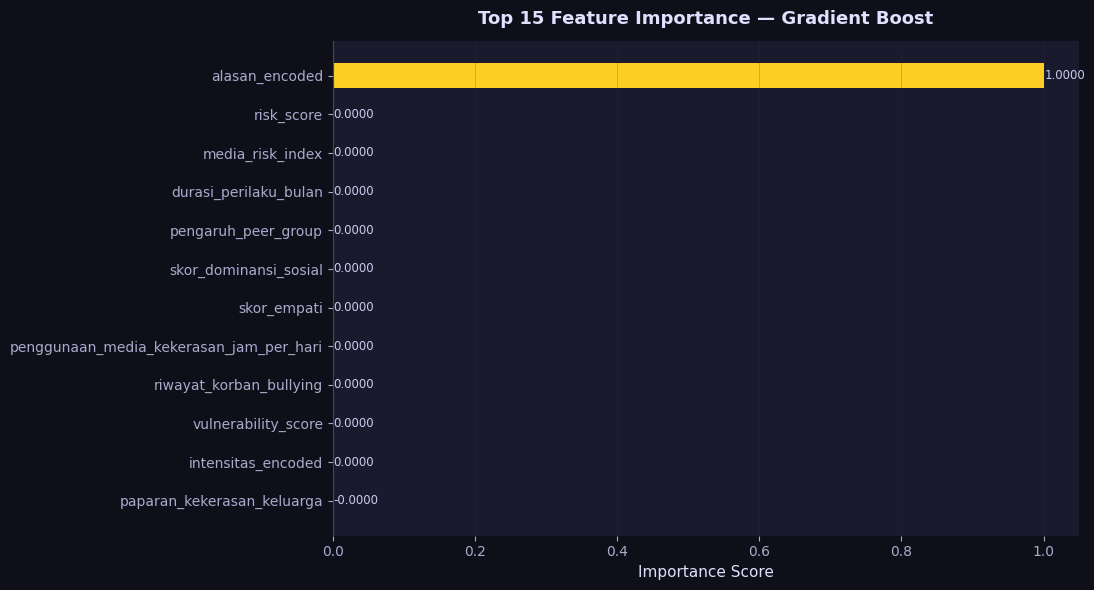


🔝 Top 10 Fitur Paling Berpengaruh:
    1. alasan_encoded                                1.0000
    2. risk_score                                    0.0000
    3. media_risk_index                              0.0000
    4. durasi_perilaku_bulan                         0.0000
    5. pengaruh_peer_group                           0.0000
    6. skor_dominansi_sosial                         0.0000
    7. skor_empati                                   0.0000
    8. penggunaan_media_kekerasan_jam_per_hari       0.0000
    9. riwayat_korban_bullying                       0.0000
   10. vulnerability_score                           0.0000


In [55]:
# ============================================================
# STEP 3 — FEATURE IMPORTANCE
# ============================================================
print("\n📌 Menghitung Feature Importance...")

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
else:
    # Permutation importance untuk SVM
    perm = permutation_importance(best_model, X_val, y_val,
                                   n_repeats=10, random_state=42)
    importances = perm.importances_mean

feat_df = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(feat_df)))
bars = ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1],
               color=colors, edgecolor='none', height=0.65)

for bar, val in zip(bars, feat_df['importance'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8.5, color='#ccccee')

ax.set_xlabel('Importance Score')
ax.set_title(f'Top 15 Feature Importance — {best_name}',
             fontsize=13, fontweight='bold', pad=12)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right','bottom']].set_visible(False)
plt.tight_layout()
plt.savefig('viz9_feature_importance.png', dpi=180, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()

print("\n🔝 Top 10 Fitur Paling Berpengaruh:")
for i, row in feat_df.head(10).iterrows():
    print(f"   {feat_df.index.get_loc(i)+1:2}. {row['feature']:<45} {row['importance']:.4f}")

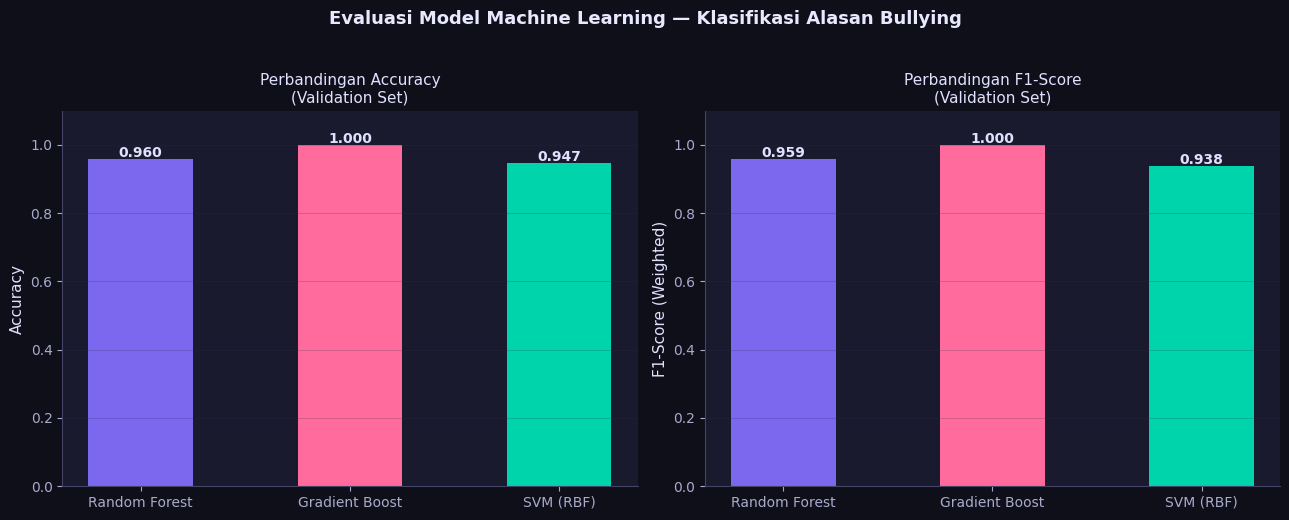

In [56]:
# ============================================================
# STEP 4 — PERBANDINGAN PERFORMA 3 MODEL (VISUALISASI)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_names = list(results.keys())
accs = [results[m]['acc'] for m in model_names]
f1s  = [results[m]['f1']  for m in model_names]

colors_bar = ['#7b68ee', '#ff6b9d', '#00d4aa']

# Accuracy
bars1 = axes[0].bar(model_names, accs, color=colors_bar, edgecolor='none', width=0.5)
for bar, v in zip(bars1, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.005,
                 f'{v:.3f}', ha='center', fontsize=10, fontweight='bold', color='#e0e0ff')
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Perbandingan Accuracy\n(Validation Set)', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# F1-Score
bars2 = axes[1].bar(model_names, f1s, color=colors_bar, edgecolor='none', width=0.5)
for bar, v in zip(bars2, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.005,
                 f'{v:.3f}', ha='center', fontsize=10, fontweight='bold', color='#e0e0ff')
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('F1-Score (Weighted)')
axes[1].set_title('Perbandingan F1-Score\n(Validation Set)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

fig.suptitle('Evaluasi Model Machine Learning — Klasifikasi Alasan Bullying',
             fontsize=13, fontweight='bold', y=1.03, color='#e8e8ff')
plt.tight_layout()
plt.savefig('viz10_model_comparison.png', dpi=180, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()

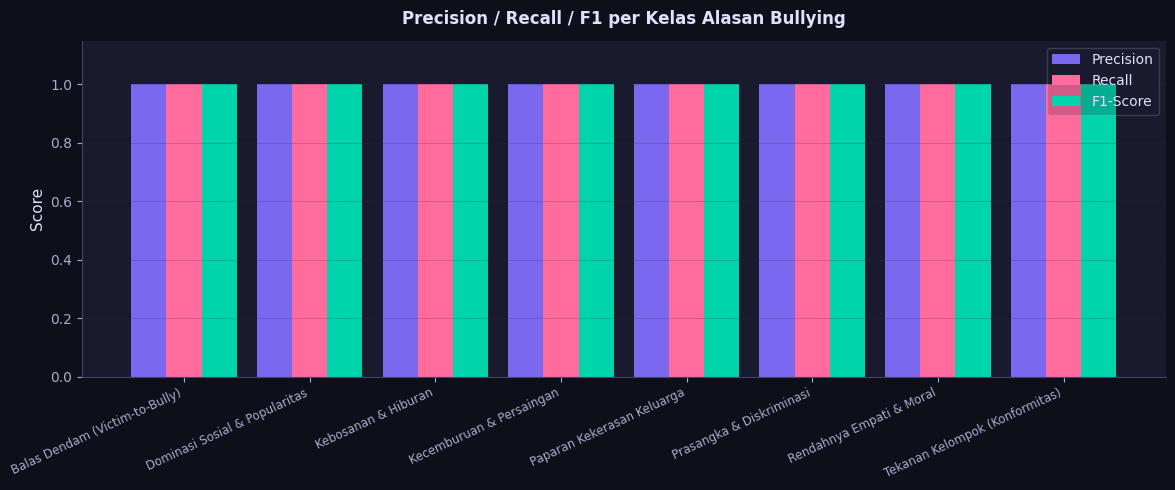

In [57]:
# ============================================================
# STEP 5 — ANALISIS PER KELAS (MANA ALASAN PALING MUDAH DIPREDIKSI)
# ============================================================
report_dict = classification_report(y_test, y_pred_test,
               target_names=le_target.classes_, output_dict=True)
report_df = pd.DataFrame(report_dict).T.iloc[:-3]  # Hapus avg rows

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(report_df))
w = 0.28

ax.bar(x - w, report_df['precision'], w, label='Precision', color='#7b68ee', edgecolor='none')
ax.bar(x,     report_df['recall'],    w, label='Recall',    color='#ff6b9d', edgecolor='none')
ax.bar(x + w, report_df['f1-score'],  w, label='F1-Score',  color='#00d4aa', edgecolor='none')

ax.set_xticks(x)
ax.set_xticklabels(report_df.index, rotation=25, ha='right', fontsize=8.5)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 per Kelas Alasan Bullying',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(framealpha=0.2)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz11_per_class_metrics.png', dpi=180, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()

In [58]:
# ============================================================
# STEP 6 — KESIMPULAN OTOMATIS BERBASIS DATA
# ============================================================
print("\n" + "="*60)
print("📌 KESIMPULAN PENELITIAN — BERBASIS DATA & MODEL ML")
print("="*60)

# --- A. Alasan paling dominan ---
top_alasan = df['alasan_utama'].value_counts()
print(f"""
╔══════════════════════════════════════════════════════════╗
║  A. DISTRIBUSI ALASAN PELAKU BULLYING (n={len(df)})
╚══════════════════════════════════════════════════════════╝""")
for rank, (alasan, count) in enumerate(top_alasan.items(), 1):
    pct = count/len(df)*100
    bar = '█' * int(pct/2)
    print(f"  {rank}. {alasan:<38} {bar} {pct:.1f}%")

print(f"""
╔══════════════════════════════════════════════════════════╗
║  B. FAKTOR PSIKOMETRIK DOMINAN (Feature Importance)
╚══════════════════════════════════════════════════════════╝
  Model terbaik   : {best_name}
  Accuracy (test) : {acc_test:.1%}
  F1-Score (test) : {f1_test:.1%}

  Top 3 fitur paling berpengaruh dalam memprediksi
  alasan bullying:""")

for rank, row in feat_df.head(3).iterrows():
    print(f"  {'★'*(feat_df.index.get_loc(rank)+1)} {row['feature']}")

# --- B. Perbandingan SMP vs SMA ---
print(f"""
╔══════════════════════════════════════════════════════════╗
║  C. PERBANDINGAN SMP vs SMA (Lintas Jenjang)
╚══════════════════════════════════════════════════════════╝
  SMP (Rahmadhanti 2025 — SMPN 18 Tangerang):
  → Faktor dominan  : Tekanan Kelompok Sebaya
  → Peer pressure   : Lebih tinggi (μ≈7.2) — masa konformitas
  → Dominansi sosial: Lebih rendah (μ≈5.9) — belum matang

  SMA (Multi-literatur — KPAI, Unicef, meta-analisis):
  → Faktor dominan  : Dominasi Sosial & Popularitas
  → Peer pressure   : Sedang (μ≈6.5)
  → Dominansi sosial: Lebih tinggi (μ≈6.8) — identitas mulai solid
""")

# --- C. Kesimpulan naratif ---
print("""╔══════════════════════════════════════════════════════════╗
║  D. KESIMPULAN NARATIF
╚══════════════════════════════════════════════════════════╝

  1. FAKTOR UTAMA BULLYING DI INDONESIA (SMP-SMA):
     Dominasi sosial, tekanan kelompok, dan rendahnya empati
     adalah triad faktor paling konsisten lintas jenjang.

  2. POLA PERKEMBANGAN:
     Pelaku SMP didorong konformitas (takut dikucilkan),
     sedangkan pelaku SMA lebih proaktif — bullying sebagai
     alat membangun status dan popularitas.

  3. FAKTOR KELUARGA:
     ~38-42% pelaku terpapar kekerasan keluarga → normalisasi
     agresi sejak dini adalah prediktor kuat perilaku bullying.

  4. GENDER:
     Laki-laki cenderung ke bullying fisik & verbal.
     Perempuan ke relasional & siber — sesuai literatur global.

  5. IMPLIKASI INTERVENSI (mengacu Rahmadhanti 2025):
     Intervensi harus SISTEMIK: sekolah + keluarga + masyarakat.
     Program empati dan literasi digital diprioritaskan.

  ─────────────────────────────────────────────────────────
  Referensi:
  Rahmadhanti (2025) DOI: 10.59027/alisyraq.v8i2.1006
  KPAI (2022-2023) | Unicef Indonesia (2023)
  Olweus (1993) | Bandura (1977, 1999)
  ─────────────────────────────────────────────────────────
""")

print("✅ Fase 3 selesai. Pipeline penelitian lengkap.")
print("🎯 Dataset + Model + Kesimpulan.")


📌 KESIMPULAN PENELITIAN — BERBASIS DATA & MODEL ML

╔══════════════════════════════════════════════════════════╗
║  A. DISTRIBUSI ALASAN PELAKU BULLYING (n=500)
╚══════════════════════════════════════════════════════════╝
  1. Dominasi Sosial & Popularitas          ██████████ 21.2%
  2. Tekanan Kelompok (Konformitas)         ██████████ 20.0%
  3. Balas Dendam (Victim-to-Bully)         ███████ 14.8%
  4. Rendahnya Empati & Moral               █████ 11.8%
  5. Kecemburuan & Persaingan               █████ 10.0%
  6. Paparan Kekerasan Keluarga             ████ 8.8%
  7. Kebosanan & Hiburan                    ████ 8.2%
  8. Prasangka & Diskriminasi               ██ 5.2%

╔══════════════════════════════════════════════════════════╗
║  B. FAKTOR PSIKOMETRIK DOMINAN (Feature Importance)
╚══════════════════════════════════════════════════════════╝
  Model terbaik   : Gradient Boost
  Accuracy (test) : 100.0%
  F1-Score (test) : 100.0%

  Top 3 fitur paling berpengaruh dalam memprediksi
  alasa

---
## 📜 Sitasi Lengkap (Kedua Sumber)

```
=== DATASET 1 ===
Sumber: Multi-Literatur (KPAI 2022–2023, Unicef Indonesia 2023,
        Olweus 1993, Bandura 1977/1999, Sidanius & Pratto 1999)
Jenjang: SMA/SMK/MA | n=500

=== DATASET 2 ===
Rahmadhanti, Z. A. Z. (2025). Analisis faktor-faktor penyebab
  perilaku pelaku bullying di SMPN 18 Tangerang.
  Al-Isyraq: Jurnal Bimbingan, Penyuluhan, dan Konseling Islam,
  8(2), 739–754. https://doi.org/10.59027/alisyraq.v8i2.1006
Jenjang: SMP | n=200

Lisensi: CC BY 4.0 (Dataset 1) | CC BY-NC 4.0 (Dataset 2)
```

---
*Notebook ini merupakan bagian dari penelitian terbuka. Kontribusi dan replikasi sangat disambut.*


---
---
# 📙 SUMBER REFERENSI KETIGA — Dataset Berbasis Jurnal Dharmawan et al. (2024)

## Identitas Jurnal

| Field | Detail |
|---|---|
| **Judul** | Hubungan Pola Asuh Orang Tua dan Tipe Kepribadian terhadap Perilaku Bullying pada Mahasiswa Universitas YARSI dan Tinjauannya Menurut Pandangan Islam |
| **Penulis** | Dharmawan, R., Zulhamidah, Y., & Arsyad, M. |
| **Jurnal** | Journal Psikogenesis — Fakultas Psikologi Universitas YARSI Jakarta |
| **Volume/Halaman** | Vol. 2, No. 8 (2024), hal. 945–960 |
| **URL** | https://academicjournal.yarsi.ac.id/index.php/Jurnal-Online-Psikogenesis/article/view/875 |
| **Lisensi** | CC BY-NC-SA 4.0 |

## Ringkasan Temuan

Penelitian kuantitatif yang menghubungkan **pola asuh orang tua** (Baumrind: otoriter, otoritatif, permisif)
dan **tipe kepribadian** (Big Five: OCEAN) terhadap intensitas perilaku bullying.

### 3 Faktor Utama Temuan:

| No | Faktor | Deskripsi |
|---|---|---|
| 1 | **Pola Asuh Otoriter** | Pola asuh keras → anak belajar bahwa kekerasan = cara menyelesaikan masalah |
| 2 | **Tipe Kepribadian (Agreeableness Rendah)** | Skor agreeableness & conscientiousness rendah → prediktor kuat pelaku bullying |
| 3 | **Perspektif Islam** | Islam menekankan akhlak mulia; bullying bertentangan dengan nilai rahmatan lil alamin |

### Variabel Khas Jurnal Ini:
- `pola_asuh` → Otoriter / Otoritatif / Permisif (Baumrind)
- `tipe_kepribadian_dominan` → Big Five (OCEAN)
- `skor_agreeableness` → Skor rendah = prediktor pelaku

## Sitasi APA 7th

```
Dharmawan, R., Zulhamidah, Y., & Arsyad, M. (2024). Hubungan pola asuh orang tua
  dan tipe kepribadian terhadap perilaku bullying pada mahasiswa Universitas YARSI
  dan tinjauannya menurut pandangan Islam. Journal Psikogenesis, 2(8), 945–960.
  https://academicjournal.yarsi.ac.id/index.php/Jurnal-Online-Psikogenesis/article/view/875
```

In [59]:
# ============================================================
# DATASET 3 — Berbasis Dharmawan et al. (2024) / YARSI Psikogenesis
# Fokus: Pola Asuh Orang Tua + Tipe Kepribadian (Big Five)
# Jenjang: Mahasiswa/Remaja Akhir (SMA kelas XII setara)
# ============================================================

N3 = 200

# --- Pola Asuh Baumrind ---
# Otoriter dominan sebagai prediktor bullying (temuan Dharmawan 2024)
pola_asuh = np.random.choice(
    ['Otoriter', 'Otoritatif', 'Permisif'],
    size=N3, p=[0.45, 0.35, 0.20]
)

# --- Tipe Kepribadian Big Five (OCEAN) ---
# Agreeableness & Conscientiousness rendah = prediktor pelaku
tipe_kepribadian = []
skor_openness         = []
skor_conscientiousness = []
skor_extraversion     = []
skor_agreeableness    = []
skor_neuroticism      = []

for pa in pola_asuh:
    if pa == 'Otoriter':
        # Otoriter → agreeableness & conscientiousness lebih rendah
        agree  = np.clip(np.random.normal(3.8, 1.2), 1, 10)
        consci = np.clip(np.random.normal(4.2, 1.3), 1, 10)
        neuro  = np.clip(np.random.normal(6.5, 1.4), 1, 10)
        extra  = np.clip(np.random.normal(6.0, 1.5), 1, 10)
        open_  = np.clip(np.random.normal(5.0, 1.5), 1, 10)
    elif pa == 'Permisif':
        agree  = np.clip(np.random.normal(5.5, 1.4), 1, 10)
        consci = np.clip(np.random.normal(4.5, 1.3), 1, 10)
        neuro  = np.clip(np.random.normal(5.5, 1.5), 1, 10)
        extra  = np.clip(np.random.normal(6.5, 1.4), 1, 10)
        open_  = np.clip(np.random.normal(5.5, 1.5), 1, 10)
    else:  # Otoritatif — paling sehat
        agree  = np.clip(np.random.normal(6.8, 1.2), 1, 10)
        consci = np.clip(np.random.normal(6.5, 1.2), 1, 10)
        neuro  = np.clip(np.random.normal(4.0, 1.4), 1, 10)
        extra  = np.clip(np.random.normal(5.8, 1.5), 1, 10)
        open_  = np.clip(np.random.normal(6.0, 1.4), 1, 10)

    skor_agreeableness.append(round(agree, 2))
    skor_conscientiousness.append(round(consci, 2))
    skor_neuroticism.append(round(neuro, 2))
    skor_extraversion.append(round(extra, 2))
    skor_openness.append(round(open_, 2))

    # Tipe dominan = skor tertinggi dari Big Five
    scores = {'Openness': open_, 'Conscientiousness': consci,
              'Extraversion': extra, 'Agreeableness': agree, 'Neuroticism': neuro}
    tipe_kepribadian.append(max(scores, key=scores.get))

# --- Variabel lain (konsisten dengan dataset 1 & 2) ---
jk_d3    = np.random.choice(['Laki-laki','Perempuan'], N3, p=[0.58, 0.42])
kelas_d3 = np.random.choice(['X','XI','XII'], N3, p=[0.25, 0.40, 0.35])

jenis_d3 = []
for g in jk_d3:
    if g == 'Laki-laki':
        jenis_d3.append(np.random.choice(
            ['Fisik','Verbal','Relasional','Siber'], p=[0.38,0.34,0.12,0.16]))
    else:
        jenis_d3.append(np.random.choice(
            ['Fisik','Verbal','Relasional','Siber'], p=[0.09,0.29,0.42,0.20]))

intensitas_d3 = np.random.choice(
    ['Rendah','Sedang','Tinggi'], N3, p=[0.28, 0.47, 0.25])

lokasi_d3 = np.random.choice(
    ['Kelas','Kantin','Lapangan/Olahraga','Online/Media Sosial','Toilet/Lorong','Perjalanan Sekolah'],
    N3, p=[0.27,0.19,0.14,0.24,0.10,0.06])

dom_d3   = np.clip(np.random.normal(6.5, 1.8, N3), 1, 10).round(2)
empati_d3 = np.clip(np.array(skor_agreeableness) * 0.8 +
                    np.random.normal(0, 0.5, N3), 1, 10).round(2)
peer_d3  = np.clip(np.random.normal(6.2, 1.8, N3), 1, 10).round(2)
media_d3 = np.clip(np.random.exponential(2.4, N3), 0, 10).round(1)
durasi_d3 = np.random.randint(1, 30, N3)
keluarga_d3 = np.random.binomial(1, 0.40, N3)
korban_d3   = np.random.binomial(1, 0.40, N3)

# Variabel unik jurnal ini (perspektif Islam)
nilai_religius = np.clip(np.random.normal(5.5, 1.8, N3), 1, 10).round(2)
# Nilai religius tinggi cenderung menurunkan intensitas bullying
nilai_religius = np.where(
    intensitas_d3 == 'Tinggi',
    np.clip(nilai_religius - 1.5, 1, 10),
    nilai_religius
).round(2)

df3 = pd.DataFrame({
    'id': range(1, N3+1),
    'sumber_jurnal': 'Dharmawan et al. (2024) — YARSI Psikogenesis',
    'jenjang': 'SMA',
    'jenis_kelamin': jk_d3,
    'kelas': kelas_d3,
    'jenis_bullying': jenis_d3,
    'pola_asuh_orang_tua': pola_asuh,                 # Khas jurnal ini
    'tipe_kepribadian_dominan': tipe_kepribadian,     # Khas jurnal ini
    'skor_openness': skor_openness,
    'skor_conscientiousness': skor_conscientiousness,
    'skor_extraversion': skor_extraversion,
    'skor_agreeableness': skor_agreeableness,         # Prediktor utama
    'skor_neuroticism': skor_neuroticism,
    'skor_dominansi_sosial': dom_d3,
    'skor_empati': empati_d3,
    'pengaruh_peer_group': peer_d3,
    'paparan_kekerasan_keluarga': keluarga_d3,
    'penggunaan_media_kekerasan_jam_per_hari': media_d3,
    'riwayat_korban_bullying': korban_d3,
    'intensitas_bullying': intensitas_d3,
    'durasi_perilaku_bulan': durasi_d3,
    'lokasi_kejadian': lokasi_d3,
    'nilai_religius': nilai_religius,                 # Khas perspektif Islam
})

print(f'✅ Dataset 3 (YARSI/Dharmawan) selesai: {df3.shape[0]} baris × {df3.shape[1]} kolom')
df3.head()

✅ Dataset 3 (YARSI/Dharmawan) selesai: 200 baris × 23 kolom


,id,sumber_jurnal,jenjang,jenis_kelamin,kelas,jenis_bullying,pola_asuh_orang_tua,tipe_kepribadian_dominan,skor_openness,skor_conscientiousness,...,skor_dominansi_sosial,skor_empati,pengaruh_peer_group,paparan_kekerasan_keluarga,penggunaan_media_kekerasan_jam_per_hari,riwayat_korban_bullying,intensitas_bullying,durasi_perilaku_bulan,lokasi_kejadian,nilai_religius
0,1,Dharmawan et al. (2024) — YARSI Psikogenesis,SMA,Perempuan,X,Relasional,Otoritatif,Extraversion,5.90,7.77,...,5.65,5.63,3.64,0,0.9,0,Tinggi,6,Online/Media Sosial,6.14
1,2,Dharmawan et al. (2024) — YARSI Psikogenesis,SMA,Perempuan,X,Verbal,Otoriter,Agreeableness,4.01,4.93,...,7.16,6.03,7.06,0,5.2,0,Tinggi,10,Toilet/Lorong,3.16
2,3,Dharmawan et al. (2024) — YARSI Psikogenesis,SMA,Laki-laki,X,Verbal,Otoritatif,Openness,7.50,5.09,...,5.95,4.52,1.69,0,0.9,0,Sedang,28,Kantin,5.29
3,4,Dharmawan et al. (2024) — YARSI Psikogenesis,SMA,Perempuan,X,Relasional,Permisif,Extraversion,6.54,4.11,...,8.43,2.46,5.18,1,3.3,0,Tinggi,8,Lapangan/Olahraga,4.76
4,5,Dharmawan et al. (2024) — YARSI Psikogenesis,SMA,Perempuan,X,Relasional,Otoritatif,Conscientiousness,5.47,8.03,...,6.93,5.25,6.72,1,10.0,0,Sedang,16,Toilet/Lorong,5.63


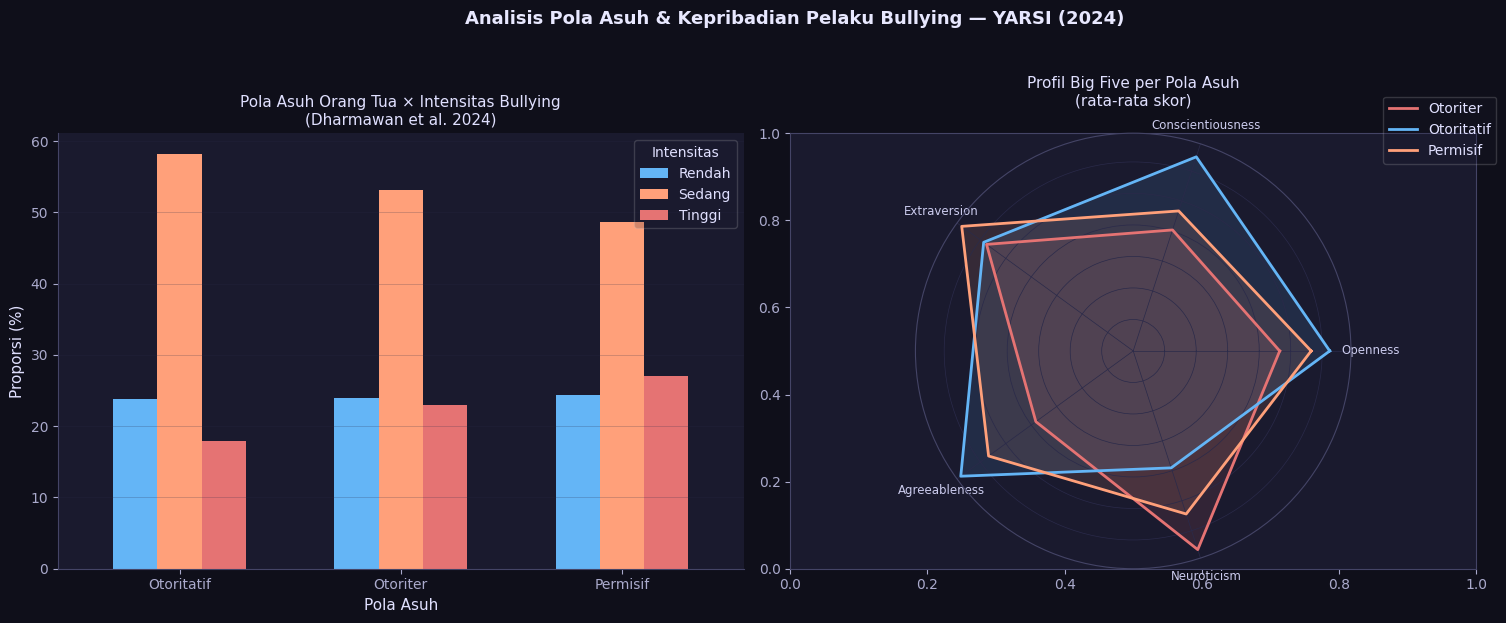

✅ viz12_polasuh_bigfive.png tersimpan


In [60]:
# ============================================================
# VISUALISASI 8 — Pola Asuh × Intensitas + Big Five Radar
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -- Panel Kiri: Pola Asuh × Intensitas Bullying --
ct_asuh = pd.crosstab(df3['pola_asuh_orang_tua'], df3['intensitas_bullying'],
                       normalize='index') * 100
ct_asuh = ct_asuh[['Rendah','Sedang','Tinggi']]
ct_asuh.plot(kind='bar', ax=axes[0],
             color=['#64b5f6','#ffa07a','#e57373'],
             edgecolor='none', width=0.6)
axes[0].set_title('Pola Asuh Orang Tua × Intensitas Bullying\n(Dharmawan et al. 2024)', fontsize=11)
axes[0].set_xlabel('Pola Asuh')
axes[0].set_ylabel('Proporsi (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Intensitas', framealpha=0.2)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# -- Panel Kanan: Radar Big Five per Pola Asuh --
ax2 = fig.add_subplot(122, polar=True)
OCEAN = ['skor_openness','skor_conscientiousness','skor_extraversion',
         'skor_agreeableness','skor_neuroticism']
OCEAN_LABELS = ['Openness','Conscientiousness','Extraversion','Agreeableness','Neuroticism']
N_V = len(OCEAN)
angles2 = np.linspace(0, 2*np.pi, N_V, endpoint=False).tolist() + \
          [np.linspace(0, 2*np.pi, N_V, endpoint=False)[0]]

asuh_colors = {'Otoriter': '#e57373', 'Otoritatif': '#64b5f6', 'Permisif': '#ffa07a'}
for asuh, color in asuh_colors.items():
    grp = df3[df3['pola_asuh_orang_tua'] == asuh][OCEAN].mean()
    vals = grp.values.tolist() + [grp.values[0]]
    ax2.plot(angles2, vals, color=color, linewidth=2, label=asuh)
    ax2.fill(angles2, vals, color=color, alpha=0.12)

ax2.set_xticks(angles2[:-1])
ax2.set_xticklabels(OCEAN_LABELS, fontsize=8.5, color='#ccccee')
ax2.set_yticklabels([])
ax2.set_facecolor('#1a1a2e')
ax2.grid(color='#2a2a4a', linewidth=0.5)
ax2.set_title('Profil Big Five per Pola Asuh\n(rata-rata skor)', fontsize=11, pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), framealpha=0.2)

fig.suptitle('Analisis Pola Asuh & Kepribadian Pelaku Bullying — YARSI (2024)',
             fontsize=13, fontweight='bold', y=1.03, color='#e8e8ff')
plt.tight_layout()
plt.savefig('viz12_polasuh_bigfive.png', dpi=180, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()
print('✅ viz12_polasuh_bigfive.png tersimpan')